## 👥 Team Members

| # | Name (English) | ID |
|---|----------------|-----|
| 1 | Omar Yasser Sayed Shafiq | 931250621 |
| 2 | Youssef Atef Tayeh | 931230366 |
| 3 | Ayman Nageh Mohamed Mohamed | 931230074 |
| 4 | Omar Mostafa Abdsttar Ali | 931250634 |
| 5 | Ibrahim Ahmed Mohamed El-Gamil | 931230004 |

---

# Movie Data Analysis Project (Refactored & Upgraded)
This Jupyter Notebook contains a production-level pipeline for the step-by-step cleaning, preprocessing, and analysis of the TMDB 5000 Movies dataset. The pipeline has been upgraded to utilize Multi-Label One-Hot Encoding for genres, ensuring unbiased and highly accurate imputation.

## 1. Import Libraries and Load Data
In this section, we import the necessary Python libraries for data manipulation and visualization and load the movie dataset into a pandas DataFrame.

**Libraries:** pandas, numpy, matplotlib, seaborn, ast  
**Dataset:** Loaded from `tmdb_5000_movies.csv`

**💡 Insight:** Setting up the environment with the correct libraries is the foundation of any data pipeline. Pandas handles data manipulation, NumPy handles numerical operations, and Matplotlib/Seaborn handle preliminary visual EDA before we move to advanced interactive Plotly charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv('../data/raw_movies.csv')

## 2. Initial Exploratory Data Analysis
Here, we perform an initial inspection to understand the dataset's structure, data types, and statistical summary.

**💡 Insight:** The initial EDA allows us to understand the shape of our data. By checking `head()`, `info()`, and `describe()`, we can quickly spot obvious anomalies, such as negative budgets or unexpectedly high max values that might indicate extreme outliers.

In [2]:
# View the first few rows
print("--- 1. First 5 Rows ---")
df.head()

--- 1. First 5 Rows ---


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:
# Check data types and non-null counts
print("\n--- 2. General Info ---")
df.info()


--- 2. General Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 

In [4]:
# View statistical summary of numerical features
print("\n--- 3. Statistical Summary ---")
df.describe()


--- 3. Statistical Summary ---


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


## 3. Data Quality Assessment
We create a summary table to track data types, the number of unique values, and the count and percentage of null values in each column to identify data quality issues.

**💡 Insight:** Creating a structured summary table highlights critical data quality gaps. Columns with a high percentage of null values (e.g., over 50%) might need to be dropped, while columns with lower null percentages are prime candidates for our advanced multi-genre imputation strategy.

In [5]:
# Create a comprehensive summary dataframe
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Null Values': [df[col].isnull().sum() for col in df.columns],
})
# Calculate the percentage of missing values
summary['Null %'] = (summary['Null Values'] / len(df)) * 100

# Sort the table by the highest percentage of missing values
summary = summary.sort_values(by='Null %', ascending=False)

# Display styled dataframe
summary.style.background_gradient(cmap='Reds')

,Column,Data Type,Unique Values,Null Values,Null %
2,homepage,object,1691,3091,64.355611
16,tagline,object,3944,844,17.572351
7,overview,object,4800,3,0.062461
13,runtime,float64,156,2,0.041641
11,release_date,object,3280,1,0.020820
3,id,int64,4803,0,0.000000
0,budget,int64,436,0,0.000000
1,genres,object,1175,0,0.000000
6,original_title,object,4801,0,0.000000
8,popularity,float64,4802,0,0.000000


## 4. Column-wise Unique Value Analysis
We iterate through each column to inspect the number of unique entries. This helps identify columns with low cardinality or specific categorical data.

**💡 Insight:** Understanding unique counts helps in identifying categorical vs. continuous data. For example, a column with only 5 unique values is categorical and perfect for grouping, whereas continuous numerical columns are better suited for histograms and scatter plots.

In [6]:
# Loop through all columns to inspect unique values
for col in df.columns:
    unique_vals = df[col].dropna().unique()
    unique_count = len(unique_vals)

    print("="*50)
    print(f"🔹 Column: {col}")
    print(f"Unique Values Count: {unique_count}")

    # If cardinality is low, display all values; otherwise, show a sample
    if unique_count <= 15:
        print("All Values:")
        print(unique_vals)
    else:
        print("Sample Values:")
        print(unique_vals[:5])

🔹 Column: budget
Unique Values Count: 436
Sample Values:
[237000000 300000000 245000000 250000000 260000000]
🔹 Column: genres
Unique Values Count: 1175
Sample Values:
['[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'
 '[{"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 28, "name": "Action"}]'
 '[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 80, "name": "Crime"}]'
 '[{"id": 28, "name": "Action"}, {"id": 80, "name": "Crime"}, {"id": 18, "name": "Drama"}, {"id": 53, "name": "Thriller"}]'
 '[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 878, "name": "Science Fiction"}]']
🔹 Column: homepage
Unique Values Count: 1691
Sample Values:
['http://www.avatarmovie.com/'
 'http://disney.go.com/disneypictures/pirates/'
 'http://www.sonypictures.com/movies/spectre/'
 'http://www.thedarkknightrises.com/'
 'http://movies.disney.com/john-carter']
🔹 Co

## 5. Analyzing Top Value Distributions
This step computes the frequency of the most common values for every column, expressed as a count and a percentage of the total dataset.

**💡 Insight:** Understanding the distribution of the top 5 values helps detect heavy imbalances (e.g., if 90% of movies are in English, language might not be a strong differentiator for all models).

In [7]:
# Analyze the top 5 most frequent values in each column
for col in df.columns:
    print("="*50)
    print(f"🔹 Column: {col}")

    vc = df[col].value_counts()

    # Get Top 5 values and their percentages
    top_vals = vc.head(5)
    percent = (top_vals / len(df)) * 100

    result = pd.DataFrame({
        'Count': top_vals,
        'Percentage (%)': percent.round(2)
    })

    print(result)

🔹 Column: budget
          Count  Percentage (%)
budget                         
0          1037           21.59
20000000    144            3.00
30000000    128            2.67
25000000    126            2.62
40000000    123            2.56
🔹 Column: genres
                                                    Count  Percentage (%)
genres                                                                   
[{"id": 18, "name": "Drama"}]                         370            7.70
[{"id": 35, "name": "Comedy"}]                        282            5.87
[{"id": 18, "name": "Drama"}, {"id": 10749, "na...    164            3.41
[{"id": 35, "name": "Comedy"}, {"id": 10749, "n...    144            3.00
[{"id": 35, "name": "Comedy"}, {"id": 18, "name...    142            2.96
🔹 Column: homepage
                                   Count  Percentage (%)
homepage                                                
http://www.thehungergames.movie/       4            0.08
http://www.missionimpossible.com/ 

## 6. Removing Irrelevant Features
We drop columns that are not useful for our analysis, such as those with too many missing values, long descriptive text, or unique identifiers. After dropping, we regenerate the data quality summary.

**💡 Insight:** Dimensionality reduction by dropping irrelevant columns (`homepage`, `overview`, etc.) improves computational efficiency and removes noise. This keeps our dataset focused purely on columns that drive analytical value and business insights.

In [8]:
# Drop irrelevant and low-value columns
df = df.drop(columns=[
    'homepage',          # contains many missing values and not useful
    'overview',          # long text, not useful for visualization
    'tagline',           # descriptive text, not analytical
    'original_title',    # duplicate of title
    'id',                # unique identifier only
    'status',            # no variation (almost all "Released")
    'keywords'           # complex JSON, not required for this analysis
])

## 7. Audit After Feature Selection
We regenerate the data quality summary to observe the status of the DataFrame after the unnecessary columns have been removed.

**💡 Insight:** Performing an audit validates our cleaning step. It confirms that the noise has been successfully removed and provides a cleaner baseline for the upcoming missing-value imputation phase.

In [9]:
# Regenerate summary to verify successful drops
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Null Values': [df[col].isnull().sum() for col in df.columns],
})

summary['Null %'] = (summary['Null Values'] / len(df)) * 100
summary = summary.sort_values(by='Null %', ascending=False)
summary.style.background_gradient(cmap='Reds')

,Column,Data Type,Unique Values,Null Values,Null %
8,runtime,float64,156,2,0.041641
6,release_date,object,3280,1,0.020820
2,original_language,object,37,0,0.000000
1,genres,object,1175,0,0.000000
0,budget,int64,436,0,0.000000
4,production_companies,object,3697,0,0.000000
3,popularity,float64,4802,0,0.000000
5,production_countries,object,469,0,0.000000
7,revenue,int64,3297,0,0.000000
9,spoken_languages,object,544,0,0.000000


## 8. Handling Missing Values
In this step, we identify and remove rows where critical information, specifically runtime and release_date, is missing.

**💡 Insight:** Since `release_date` is critical for our time-series analysis (Week 8 & 9) and dropping a few rows is statistically insignificant compared to the whole dataset, removing them outright is safer than guessing a random date.

In [10]:
# Identify rows with critical missing values
missing_rows = df[df['runtime'].isnull() | df['release_date'].isnull()]
missing_rows

,budget,genres,original_language,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
2656,15000000,"[{""id"": 18, ""name"": ""Drama""}]",it,0.738646,"[{""name"": ""Taodue Film"", ""id"": 45724}]","[{""iso_3166_1"": ""IT"", ""name"": ""Italy""}]",2015-12-03,0,NaN,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Chiamatemi Francesco - Il Papa della gente,7.3,12
4140,2,"[{""id"": 99, ""name"": ""Documentary""}]",en,0.050625,"[{""name"": ""Eyeline Entertainment"", ""id"": 60343}]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2015-12-12,0,NaN,[],"To Be Frank, Sinatra at 100",0.0,0
4553,0,[],en,0.000000,[],[],NaN,0,0.0,[],America Is Still the Place,0.0,0


In [11]:
# Drop these corrupted rows
df = df.dropna(subset=['runtime', 'release_date'])
print("Null values after dropping:")
print(df.isnull().sum())

Null values after dropping:
budget                  0
genres                  0
original_language       0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
title                   0
vote_average            0
vote_count              0
dtype: int64


## 9. Investigation of Zero-Value Anomalies
We inspect numeric columns for zero values, which often indicate missing data in financial fields (like budget or revenue) or potential recording errors.

**💡 Insight:** A movie cannot realistically have a $0 budget or generate $0 revenue if it was released globally. Identifying these logical anomalies is crucial because treating $0 as an actual value would severely distort our averages and ROI calculations later.

In [12]:
# Find numeric columns that contain zeros
zero_cols = [col for col in df.columns
             if pd.api.types.is_numeric_dtype(df[col]) and (df[col] == 0).sum() > 0]

# Report the count and percentage of zeros
for col in zero_cols:
    print("\n" + "="*60)
    print(f"Column: {col}")
    print("="*60)

    zero_count = (df[col] == 0).sum()
    total = len(df)

    print(f"Zero Count     : {zero_count}")
    print(f"Total Rows     : {total}")
    print(f"Zero Percentage: {(zero_count / total) * 100:.2f}%")

    print("\nSample Zero Rows:")
    display(df[df[col] == 0][['title', col]].head(5))


Column: budget
Zero Count     : 1036
Total Rows     : 4800
Zero Percentage: 21.58%

Sample Zero Rows:


,title,budget
265,The Cat in the Hat,0
321,The Campaign,0
359,Alvin and the Chipmunks: The Road Chip,0
406,Arthur Christmas,0
409,All That Jazz,0



Column: revenue
Zero Count     : 1424
Total Rows     : 4800
Zero Percentage: 29.67%

Sample Zero Rows:


,title,revenue
83,The Lovers,0
135,The Wolfman,0
265,The Cat in the Hat,0
309,Son of the Mask,0
376,Volcano,0



Column: runtime
Zero Count     : 34
Total Rows     : 4800
Zero Percentage: 0.71%

Sample Zero Rows:


,title,runtime
1011,The Tooth Fairy,0.0
3112,Blood Done Sign My Name,0.0
3669,Should've Been Romeo,0.0
3809,How to Fall in Love,0.0
3953,Fort McCoy,0.0



Column: vote_average
Zero Count     : 61
Total Rows     : 4800
Zero Percentage: 1.27%

Sample Zero Rows:


,title,vote_average
1464,Black Water Transit,0.0
3669,Should've Been Romeo,0.0
3670,Running Forever,0.0
3852,The Secret,0.0
3855,Time to Choose,0.0



Column: vote_count
Zero Count     : 60
Total Rows     : 4800
Zero Percentage: 1.25%

Sample Zero Rows:


,title,vote_count
1464,Black Water Transit,0
3669,Should've Been Romeo,0
3670,Running Forever,0
3852,The Secret,0
3855,Time to Choose,0


In [13]:
df.shape

(4800, 13)

## 10. Genre Extraction and Budget Imputation
We extract the primary genre from the JSON-like `genres` column using Multi-Label One-Hot Encoding. We then address zero values in the `budget` column by filling them with the median budget of the respective genres.

**💡 Insight:** Movies often belong to multiple genres. Using a custom Multi-Genre Imputation logic prevents bias (e.g., treating an "Action/Comedy" only as an "Action" film). This provides a much more accurate estimation for missing budgets.

In [14]:
# ===============================
# 1. Extract ALL Genres into lists
# ===============================
def extract_all_genres(text):
    try:
        genres = [i['name'] for i in ast.literal_eval(text)]
        return genres if genres else ['Unknown']
    except:
        return ['Unknown']

df['genre_list'] = df['genres'].apply(extract_all_genres)

# ===============================
# 2. Multi-Label One-Hot Encoding
# ===============================
# Identify all unique genres across the entire dataset
all_unique_genres = set([genre for sublist in df['genre_list'] for genre in sublist])

# Create binary columns for each genre
for genre in all_unique_genres:
    # Prefixing with 'genre_' to keep columns organized
    df[f'genre_{genre}'] = df['genre_list'].apply(lambda x: 1 if genre in x else 0)

# ===============================
# 3. Helper Function for Multi-Genre Imputation
# ===============================
def multi_genre_impute(dataframe, target_col, agg_method='median'):
    """
    Imputes missing values based on the average of the aggregates (mean/median)
    of all genres a movie belongs to.
    """
    temp_df = dataframe.copy()

    # Calculate target aggregate for each genre individually
    genre_aggs = {}
    for genre in all_unique_genres:
        genre_mask = temp_df[f'genre_{genre}'] == 1
        if agg_method == 'median':
            val = temp_df.loc[genre_mask, target_col].median()
        else:
            val = temp_df.loc[genre_mask, target_col].mean()
        genre_aggs[genre] = val

    # Function to apply to missing rows
    def calculate_imputation_value(movie_genres):
        valid_aggs = [genre_aggs[g] for g in movie_genres if pd.notna(genre_aggs.get(g))]
        if valid_aggs:
            return np.mean(valid_aggs) # Average of the respective genre medians/means
        return np.nan

    # Apply to missing rows
    missing_mask = temp_df[target_col].isna()
    temp_df.loc[missing_mask, target_col] = temp_df.loc[missing_mask, 'genre_list'].apply(calculate_imputation_value)

    # Global fallback just in case
    global_agg = temp_df[target_col].median() if agg_method == 'median' else temp_df[target_col].mean()
    temp_df[target_col] = temp_df[target_col].fillna(global_agg)

    return temp_df[target_col]

# ===============================
# 4. Impute Budget
# ===============================
# Replace zeros with NaN to prepare for imputation
df['budget'] = df['budget'].replace(0, np.nan)

# Fill missing budgets using our multi-genre median approach
df['budget'] = multi_genre_impute(df, target_col='budget', agg_method='median')

print("Remaining missing budgets:", df['budget'].isna().sum())

Remaining missing budgets: 0


## 11. Voting Analysis and Weighted Rating
We clean the voting metrics and calculate a "Weighted Rating." This formula uses a Bayesian approach to account for both the average rating and the number of votes, ensuring movies with very few votes don't skew the results.

**💡 Insight:** A movie with a 10/10 rating from only 2 voters is not necessarily better than a movie with an 8.5/10 from 5,000 voters. The Bayesian weighted rating solves this by penalizing movies with low vote counts, bringing their score closer to the overall dataset average.

In [15]:
# ===============================
# 1. Clean vote_average
# ===============================
# If no votes, the rating is invalid
df.loc[df['vote_count'] == 0, 'vote_average'] = np.nan

# If there are votes but average is 0, this is likely a recording error
df.loc[(df['vote_count'] > 0) & (df['vote_average'] == 0), 'vote_average'] = np.nan

# ===============================
# 2. Impute vote_average using Multi-Genre Logic
# ===============================
df['vote_average'] = multi_genre_impute(df, target_col='vote_average', agg_method='mean')

# ===============================
# 3. Calculate Weighted Rating
# ===============================
# C represents the mean vote across the whole dataset
C = df['vote_average'].mean()

# m represents the minimum votes required to be listed (60th percentile)
m = df['vote_count'].quantile(0.60)

# Bayesian formula calculation
df['weighted_rating'] = (
    (df['vote_count'] / (df['vote_count'] + m)) * df['vote_average'] +
    (m / (df['vote_count'] + m)) * C
)

print(df[['title', 'vote_average', 'vote_count', 'weighted_rating']].head())

                                      title  vote_average  vote_count  \
0                                    Avatar           7.2       11800   
1  Pirates of the Caribbean: At World's End           6.9        4500   
2                                   Spectre           6.3        4466   
3                     The Dark Knight Rises           7.6        9106   
4                               John Carter           6.1        2124   

   weighted_rating  
0         7.168615  
1         6.844430  
2         6.290060  
3         7.544035  
4         6.110468  


## 12. Revenue Analysis and Flagging
We create a `revenue_flag` column to categorize movies. This distinguishes between movies with valid revenue, missing revenue data, or potential box-office flops.

**💡 Insight:** Not all $0 revenues are missing data; some indie movies legitimately flop at the box office. By using popularity and vote counts, we smartly differentiate between a 'flop' and purely 'missing data', ensuring we only impute what's logically missing.

In [16]:
# ===============================
# 1. Flagging Revenue
# ===============================
df['revenue_flag'] = 'valid'

# Flag as missing: 0 revenue but high engagement
df.loc[
    (df['revenue'] == 0) &
    (df['vote_count'] > 100) &
    (df['popularity'] > df['popularity'].median()),
    'revenue_flag'
] = 'missing'

# Flag as possible flop: 0 revenue and low engagement
df.loc[
    (df['revenue'] == 0) &
    (df['vote_count'] <= 100),
    'revenue_flag'
] = 'possible_flop'

print("Revenue Flags Distribution:")
print(df['revenue_flag'].value_counts())

# ===============================
# 2. Impute ONLY 'missing' revenues
# ===============================
# Temporarily set missing flags to NaN so the multi_genre_impute function can target them
# Note: 'possible_flop' stays as 0 and 'valid' stays as is
df.loc[df['revenue_flag'] == 'missing', 'revenue'] = np.nan

# Apply multi-genre median imputation
df['revenue'] = multi_genre_impute(df, target_col='revenue', agg_method='median')

print("\nSample of imputed 'missing' revenues:")
display(df[df['revenue_flag'] == 'missing'][['title', 'budget', 'revenue', 'vote_count', 'popularity']].head())

Revenue Flags Distribution:
revenue_flag
valid            3596
possible_flop    1069
missing           135
Name: count, dtype: int64

Sample of imputed 'missing' revenues:


,title,budget,revenue,vote_count,popularity
135,The Wolfman,1.500000e+08,1.978290e+07,549,21.214571
265,The Cat in the Hat,4.233333e+07,6.197571e+07,366,18.251129
309,Son of the Mask,8.400000e+07,7.096145e+07,338,17.815595
376,Volcano,9.000000e+07,3.773033e+07,376,19.836124
406,Arthur Christmas,4.025000e+07,5.969400e+07,333,19.836830


## 13. Runtime Cleaning & Final Verification
We address zero values in the `runtime` column using our multi-genre median logic.

**💡 Insight:** Similar to financial data, a runtime of 0 is physically impossible for a released movie. Imputing it by genre is accurate, as Animations tend to be shorter (~90 mins) while Epics/Dramas run longer (~120+ mins).

In [17]:
# ===============================
# 1. Replace illogical 0 runtimes with NaN
# ===============================
df['runtime'] = df['runtime'].replace(0, np.nan)

# ===============================
# 2. Impute using Multi-Genre Median Logic
# ===============================
df['runtime'] = multi_genre_impute(df, target_col='runtime', agg_method='median')

# ===============================
# 3. Final Verification
# ===============================
print("Remaining zeros in runtime:", (df['runtime'] == 0).sum())
print("Remaining nulls in runtime:", df['runtime'].isnull().sum())

Remaining zeros in runtime: 0
Remaining nulls in runtime: 0


## 14. Outlier Detection
Outliers are extreme values that deviate significantly from other observations in the dataset. In movie data, blockbusters with massive budgets or revenues can act as outliers, potentially skewing statistical analyses and impacting the performance of certain Machine Learning models.

In this section, we use boxplots to visually inspect the distribution and identify potential outliers across four key numerical features: `budget`, `revenue`, `runtime`, and `vote_count`.

**💡 Insight:** The boxplots will likely reveal massive right-skewness. A few mega-blockbusters (like *Avatar*) dominate the revenue scale. Recognizing these outliers is step one before deciding how to handle them without destroying their business value.

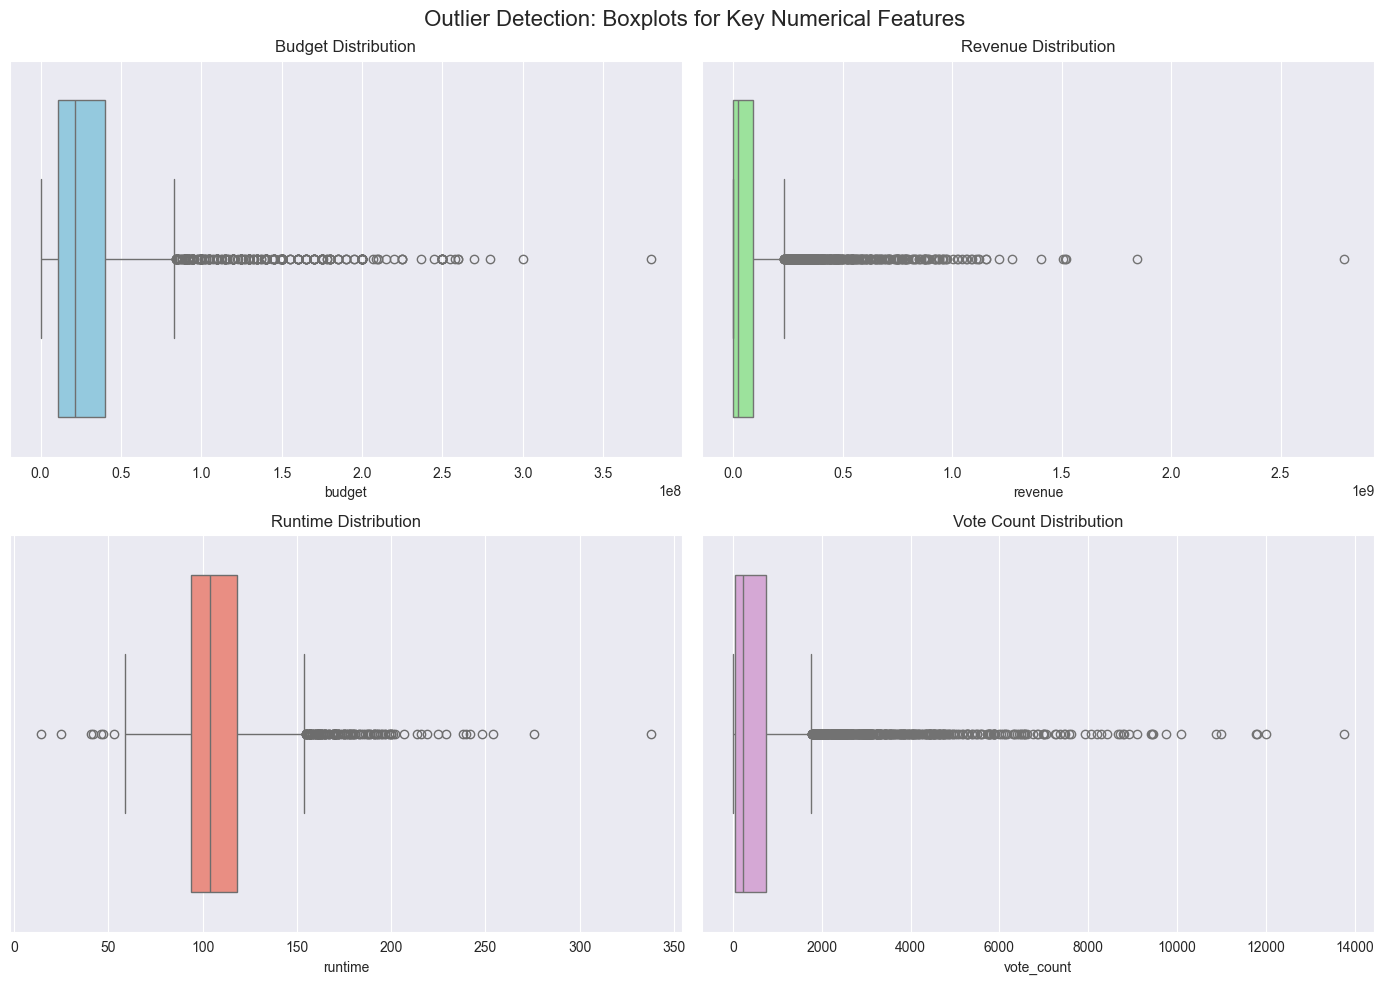

In [18]:
# Set up the matplotlib figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Outlier Detection: Boxplots for Key Numerical Features', fontsize=16)

# Create boxplots
sns.boxplot(ax=axes[0, 0], data=df, x='budget', color='skyblue')
axes[0, 0].set_title('Budget Distribution')

sns.boxplot(ax=axes[0, 1], data=df, x='revenue', color='lightgreen')
axes[0, 1].set_title('Revenue Distribution')

sns.boxplot(ax=axes[1, 0], data=df, x='runtime', color='salmon')
axes[1, 0].set_title('Runtime Distribution')

sns.boxplot(ax=axes[1, 1], data=df, x='vote_count', color='plum')
axes[1, 1].set_title('Vote Count Distribution')

plt.tight_layout()
plt.show()

## 15. Outlier Treatment (Log Transformation)
In the context of the film industry, extreme values—such as the massive budgets or unprecedented box office revenues of blockbusters like *Avatar* or *Avengers*—are genuine, highly valuable data points rather than recording errors.

Applying traditional capping methods (like IQR-based winsorization) to these financial features would distort real-world financial signals and cause a massive loss of critical information. However, financial features are natively highly right-skewed, which can degrade the performance of many Machine Learning algorithms.

Instead of capping, we apply a **Logarithmic Transformation** using `np.log1p` (which calculates log(x + 1) to safely handle any zeros). This approach is far superior because it:
* **Preserves true distributions:** It keeps the absolute ranking of movies intact without throwing away blockbuster data.
* **Reduces skewness:** It compresses the long tail of the distribution, pulling extreme values closer to the center.
* **Enhances modeling and visualization:** It creates a more normalized, bell-shaped distribution, which linear models and distance-based algorithms handle much better.

We will create new transformed columns (`log_budget` and `log_revenue`) to ensure the original raw financial data remains perfectly untouched for accurate reporting.

**💡 Insight:** Log transformation is the industry standard for financial modeling. It compresses the gap between a $10M and a $1B movie so models can understand relationships better, without deleting the billion-dollar movie from the dataset.

In [19]:
# Apply log(x + 1) transformation to handle high right-skewness safely
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])

# Verify the new columns alongside the originals
display(df[['title', 'budget', 'log_budget', 'revenue', 'log_revenue']].head(10))

,title,budget,log_budget,revenue,log_revenue
0,Avatar,237000000.0,19.283571,2.787965e+09,21.748578
1,Pirates of the Caribbean: At World's End,300000000.0,19.519293,9.610000e+08,20.683485
2,Spectre,245000000.0,19.316769,8.806746e+08,20.596199
3,The Dark Knight Rises,250000000.0,19.336971,1.084939e+09,20.804790
4,John Carter,260000000.0,19.376192,2.841391e+08,19.464974
5,Spider-Man 3,258000000.0,19.368470,8.908716e+08,20.607711
6,Tangled,260000000.0,19.376192,5.917949e+08,20.198671
7,Avengers: Age of Ultron,280000000.0,19.450300,1.405404e+09,21.063590
8,Harry Potter and the Half-Blood Prince,250000000.0,19.336971,9.339592e+08,20.654943
9,Batman v Superman: Dawn of Justice,250000000.0,19.336971,8.732602e+08,20.587744


## 16. Feature Engineering (Advanced & Temporal)
Feature engineering involves creating new variables from existing ones to provide deeper insights. In this section, We extract financial (`profit`, `ROI`, `performance_status`) and temporal features (`Year`, `Month`, `Day`).

**1. Financial & Categorical Features:**
* **Profit:** The absolute financial gain (`revenue - budget`).
* **ROI (Return on Investment):** A ratio showing the efficiency of the budget (`revenue / budget`).
* **Performance Status:** Categorizing movies into 'Profit' or 'Loss' based on whether their revenue exceeded their budget.

**2. Temporal Features:**
* Extracting **Year, Month, and Day** from the `release_date` to allow for time-series analysis and seasonality checks.

*Note: We also implement safe handling for division by zero in ROI to prevent infinite values (`inf`), replacing them with `NaN` and safely filling them with 0.*

**💡 Insight:** Raw revenue doesn't tell the whole story. A movie that makes $100M is a flop if its budget was $200M (Loss). ROI and Profit are the true KPIs that production companies care about when assessing a movie's financial success.

In [20]:
# ==========================================
# 1. Financial & Categorical Feature Engineering
# ==========================================
# Calculate Profit and ROI
df['profit'] = df['revenue'] - df['budget']
df['ROI'] = df['revenue'] / df['budget']

# Handle infinite values (division by zero) and NaNs safely
df['ROI'] = df['ROI'].replace([np.inf, -np.inf], np.nan)
df['ROI'] = df['ROI'].fillna(0)

# Identify movies where revenue < budget (The "Loss" logic)
df['performance_status'] = np.where(df['revenue'] < df['budget'], 'Loss', 'Profit')

# ==========================================
# 2. Temporal Feature Engineering
# ==========================================
# Ensure release_date is in datetime format
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Extract Year, Month, and Day
df['release_year'] = df['release_date'].dt.year.astype('Int64')
df['release_month'] = df['release_date'].dt.month.astype('Int64')
df['release_day'] = df['release_date'].dt.day.astype('Int64')

# ==========================================
# 3. Verify Engineered Features
# ==========================================
print("--- Performance Status Breakdown ---")
display(df['performance_status'].value_counts().to_frame())

print("\n--- Sample of Movies with Revenue < Budget ---")
display(df[df['performance_status'] == 'Loss'][['title', 'budget', 'revenue', 'profit', 'performance_status']].head())

print("\n---  Sample of Temporal Features ---")
display(df[['title', 'release_date', 'release_year', 'release_month', 'release_day']].head(3))

--- Performance Status Breakdown ---


,count
performance_status,
Profit,2562
Loss,2238



--- Sample of Movies with Revenue < Budget ---


,title,budget,revenue,profit,performance_status
13,The Lone Ranger,255000000.0,8.928991e+07,-1.657101e+08,Loss
73,Evan Almighty,175000000.0,1.730000e+08,-2.000000e+06,Loss
83,The Lovers,27000000.0,0.000000e+00,-2.700000e+07,Loss
84,47 Ronin,175000000.0,1.509625e+08,-2.403752e+07,Loss
135,The Wolfman,150000000.0,1.978290e+07,-1.302171e+08,Loss



---  Sample of Temporal Features ---


,title,release_date,release_year,release_month,release_day
0,Avatar,2009-12-10,2009,12,10
1,Pirates of the Caribbean: At World's End,2007-05-19,2007,5,19
2,Spectre,2015-10-26,2015,10,26


## 17. Correlation Analysis
Correlation measures the linear relationship between numerical variables. Understanding these relationships helps us identify which features strongly influence each other (e.g., does a higher budget guarantee higher revenue? Does a longer runtime affect the vote average?).

We use a Seaborn heatmap to visualize the correlation matrix. By including our newly engineered features (`log_budget` and `log_revenue`), we can observe how normalizing the financial distributions provides a clearer, often stronger, linear correlation with other metrics compared to the highly skewed raw data. Values closer to **1** indicate a strong positive correlation, while values closer to **-1** indicate a strong negative correlation.

**💡 Insight:** The heatmap quickly validates assumptions. For instance, you will likely see a strong positive correlation between `vote_count` and `revenue`, indicating that highly discussed movies usually generate high box-office numbers.

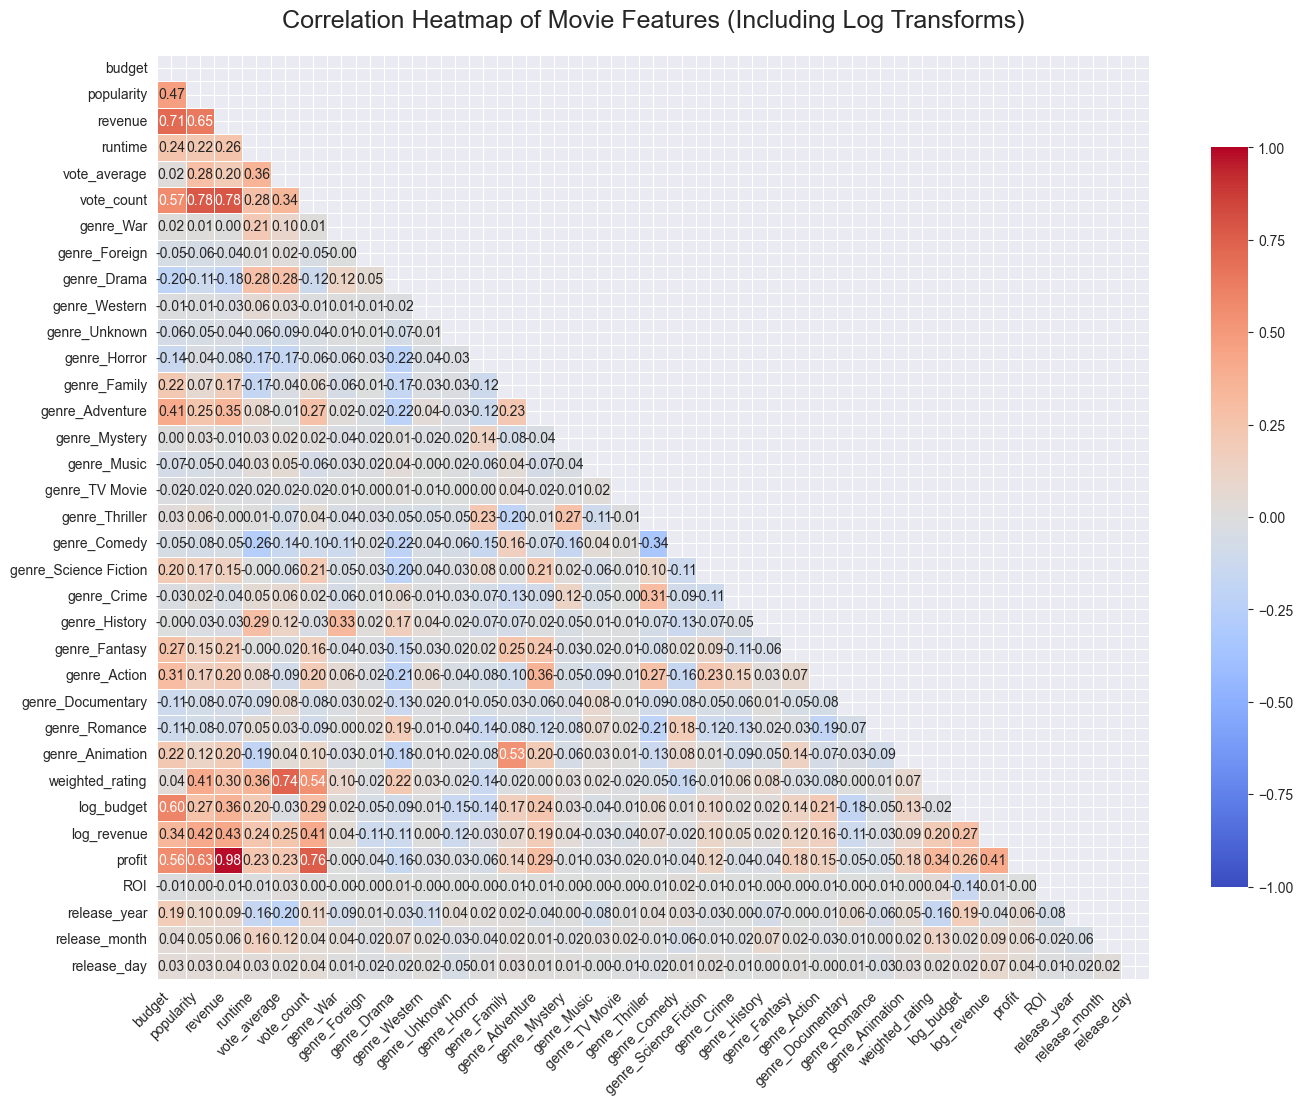

In [21]:
# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Calculate the correlation matrix (strictly for numerical columns)
corr_matrix = df.corr(numeric_only=True)

# Generate a mask for the upper triangle (for a cleaner visual)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
# ❗ correlation ≠ causation
plt.title('Correlation Heatmap of Movie Features (Including Log Transforms)', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

## 18. Save Cleaned Dataset (For Dashboard Integration)
Before moving into advanced Plotly visualizations, we must save our pristine, fully preprocessed dataset. This ensures that our final dashboard (e.g., `app.py`) reads directly from a clean source without needing to run preprocessing steps on every load.

**Insight:** Decoupling data preprocessing from dashboard visualization is a software engineering best practice. Saving to `../data/cleaned_movies.csv` aligns with our project directory structure and guarantees consistent data states across all scripts.

In [22]:
# Save to the specific data directory
df.to_csv('../data/cleaned_movies.csv', index=False)
print("\n Data preprocessing COMPLETE. File successfully saved to '../data/cleaned_movies.csv'.")


 Data preprocessing COMPLETE. File successfully saved to '../data/cleaned_movies.csv'.


## 19. Dashboard Visualizations (Plotly Guidelines Applied)
In this final section, we build interactive, production-ready Plotly charts.

**Insight:** All charts strictly follow specific Data Visualization Guidelines (Rules 1-10):
- **Rule 1:** Black chart borders (`mirror=True`, `showline=True`).
- **Rule 2:** Zero baselines (`rangemode="tozero"`).
- **Rule 8:** Cohesive color strategies (Black fonts, distinct `lightblue` / `plum` / `lightgreen` palettes).
- **Transparency & Legibility:** Legends have transparent white backgrounds so they don't block critical data points.

In [23]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import calendar
import ast


df = pd.read_csv('../data/cleaned_movies.csv')


def get_primary_name(data_str):
    try:
        data = ast.literal_eval(data_str)
        return data[0]['name'] if len(data) > 0 else 'Unknown'
    except:
        return 'Unknown'

if 'primary_company' not in df.columns:
    df['primary_company'] = df['production_companies'].apply(get_primary_name)

df['Decade'] = (df['release_year'] // 10) * 10
df['Decade_Str'] = df['Decade'].astype(str) + 's'

## 1. Column Chart: Seasonal Impact on Movie Profitability

**Objective:** This analysis investigates the relationship between a movie's release timing and its overall financial success. By evaluating the average profit generated across different months, we aim to identify the optimal release windows that maximize the return on investment for production studios.

**Visual Strategy:**
* **Metric:** Average Absolute Profit (Revenue - Budget).
* **Highlighting:** The highest-performing month is distinctly highlighted in green to immediately draw stakeholders' attention to the most lucrative release window.
* **Formatting:** Gridlines are restricted to the Y-axis to maintain a clean aesthetic, while large numbers are abbreviated (e.g., 'M' for Millions) to prevent visual clutter.

In [24]:
df_month = df.dropna(subset=['release_month']).groupby('release_month')['profit'].mean().reset_index()
df_month['Month'] = df_month['release_month'].apply(lambda x: calendar.month_abbr[int(x)])

colors1 = ['lightblue'] * len(df_month)
colors1[df_month['profit'].idxmax()] = 'lightgreen'

fig1 = go.Figure(go.Bar(
    x=df_month['Month'], y=df_month['profit'],
    text=(df_month['profit'] / 1e6).round(1).astype(str) + 'M',
    textposition='outside', marker_color=colors1, marker_line=dict(color='black', width=1)
))

fig1.update_layout(
    title=dict(text="Average Profit by Release Season", font=dict(color='black', size=18), x=0.5),
    plot_bgcolor='white', paper_bgcolor='white',
    # X-Axis: No Gridlines
    xaxis=dict(title="Release Month", color='black', showgrid=False, showline=True, linecolor='black', linewidth=2, mirror=True),
    # Y-Axis: Horizontal Gridlines Only
    yaxis=dict(title="Avg Profit ($)", color='black', showgrid=True, gridcolor='LightGray', range=[0, df_month['profit'].max()*1.15], rangemode="tozero", showline=True, linecolor='black', linewidth=2, mirror=True),
    font=dict(color='black')
)
fig1.show()

### 💡 Strategic Business Insights

The visualization reveals significant fluctuations in profitability depending on the time of year. Understanding this seasonality is critical for production studios and distributors when scheduling global premieres.

* **The Blockbuster Windows:** Certain periods—most notably the peak summer months and the end-of-year holiday season—demonstrate a massive spike in average profitability. During these times, target demographics (such as students and families) have more free time, leading to higher box office turnouts.
* **The "Dump Months":** Conversely, specific periods show a distinct dip in average profits. Studios traditionally avoid releasing high-budget, high-risk films during these lower-performing months due to historically weaker consumer spending on theatrical entertainment.
* **Timing as a Multiplier:** The data confirms that releasing a movie is not solely about content quality; launch timing acts as a significant financial multiplier. A well-timed release can elevate a mid-tier movie, while a poor release window can financially suppress a high-quality film.

### 📅 Seasonal Release Strategy Matrix

Based on the historical profit distributions, stakeholders can utilize the following matrix to align their movie types with the most appropriate release windows:

| Release Window | Key Months | Financial Expectation | Strategic Recommendation |
| :--- | :--- | :--- | :--- |
| **Peak Summer** | May, June, July | Highest potential profit ceilings. | Reserve strictly for mega-budget blockbusters, action franchises, and highly anticipated sequels. |
| **Holiday Season** | November, December | Strong, sustained profitability. | Ideal for family-oriented films, major animations, and high-profile award contenders. |
| **Shoulder Seasons** | March, April, October | Moderate to volatile profits. | Suitable for mid-budget films, experimental genres, and horror movies (specifically October). |
| **Low Season** | January, February, August| Lowest historical average profit. | Best utilized for low-budget indie films, thrillers, or niche movies to avoid heavy blockbuster competition. |

---

---

## 2. Horizontal Bar Chart: Industry Titans by Total Profit

**Objective:** This visualization shifts the focus from individual movie metrics to corporate performance, ranking the top 15 production companies by their total accumulated profit. It serves to identify the dominant market leaders and trace where the bulk of the industry's wealth is concentrated.

**Visual Strategy:**
* **Layout:** A horizontal bar chart is utilized to ensure the long corporate names remain perfectly legible on the Y-axis without any text overlapping or awkward tilting.
* **Highlighting:** The leading studio is highlighted in green, instantly establishing the industry benchmark and separating the absolute leader from the rest of the pack.
* **Formatting:** Values are aggregated and formatted in Billions (B) to reflect the true macro-scale of these corporate conglomerates, with vertical gridlines explicitly guiding the eye across the financial magnitudes.

In [25]:
# =========================================================
# 1. Data Preparation
# =========================================================
def get_primary_company(comp_str):
    try:
        comps = ast.literal_eval(comp_str)
        return comps[0]['name'] if len(comps) > 0 else 'Unknown'
    except:
        return 'Unknown'

# Extract the primary company if not already done
if 'primary_company' not in df.columns:
    df['primary_company'] = df['production_companies'].apply(get_primary_company)

# Group by company and calculate total profit
df_company = df.groupby('primary_company')['profit'].sum().reset_index()

# Filter out 'Unknown' and get the Top 15
df_top15 = df_company[df_company['primary_company'] != 'Unknown']
df_top15 = df_top15.sort_values('profit', ascending=False).head(15)

# Order ascending so the largest value appears at the TOP of the horizontal bar chart
df_plot = df_top15.sort_values('profit', ascending=True).reset_index(drop=True)

# Calculate max profit to extend the x-axis properly
max_profit = df_plot['profit'].max()

# =========================================================
# 2. Styling Rules & Formats
# =========================================================
# Rule 4: Color Strategy (Uniform light blue, highlight highest with light green)
colors = ['lightblue'] * len(df_plot)
if len(colors) > 0:
    colors[-1] = 'lightgreen'  # Highest profit company

# Rule 5: Show Magnitudes (Format values in Billions e.g., 25.49B)
text_labels = (df_plot['profit'] / 1e9).round(2).astype(str) + 'B'

# =========================================================
# 3. Building the Plotly Chart
# =========================================================
fig = go.Figure(data=[
    go.Bar(
        x=df_plot['profit'],
        y=df_plot['primary_company'],
        orientation='h',
        text=text_labels,
        textposition='outside', # Display text outside the bars
        marker_color=colors,
        # Rule 8: Optional Enhancement (Hover Template for exact details)
        hovertemplate="<b>Company:</b> %{y}<br><b>Exact Profit:</b> $%{x:,.0f}<extra></extra>"
    )
])

fig.update_layout(
    # Rule 2: Title horizontally centered with units
    title=dict(
        text="Top 15 Production Companies by Total Profit (USD)",
        font=dict(color='black', size=18),
        x=0.5,             # Center horizontally
        xanchor='center'
    ),

    # Rule 1: Remove legend since there is only one data series
    showlegend=False,

    # Rule 6: Clean white background
    plot_bgcolor='white',
    paper_bgcolor='white',

    # Rule 3 & 6: X-axis formatting, gridlines, and borders
    xaxis=dict(
        title="Total Profit (USD)",
        range=[0, max_profit * 1.15], # Extend by 15% to prevent text overlap
        rangemode="tozero",
        color='black',
        showgrid=True, gridwidth=1, gridcolor='LightGray',
        showline=True, linecolor='black', linewidth=2, mirror=True # Black frame
    ),

    # Rule 3 & 6: Y-axis formatting and borders
    yaxis=dict(
        title="Production Company",
        tickangle=0,       # Keep text horizontal
        color='black',
        showline=True, linecolor='black', linewidth=2, mirror=True # Black frame
    ),

    # Rule 6: Layout spacing
    height=700,
    font=dict(color='black')
)

fig.show()

### 💡 Strategic Business Insights

Analyzing absolute profit at the corporate level reveals the macroscopic power dynamics of the film industry. This chart moves beyond the success of a single film to evaluate the sustained financial engines of major studios.

* **The "Big Studio" Monopoly:** The visualization immediately confirms market concentration at the top. A select few legacy studios capture the lion's share of global box office profits. Their success is driven by massive distribution networks, established marketing machinery, and ownership of legacy intellectual properties (IPs).
* **Scale and Volume:** Companies at the top of this list achieve these staggering billion-dollar figures through sheer volume—releasing multiple high-budget blockbuster films globally every year. This highlights a business model built on massive scale and market saturation.
* **Strategic Partnerships:** For independent filmmakers, smaller production houses, or corporate investors, this ranking acts as a primary target list. Securing a co-production or distribution deal with a top-tier studio significantly mitigates risk and virtually guarantees global theatrical placement.

### 🏢 Production Studio Tier Matrix

To make these corporate findings actionable for stakeholders, the production companies can be classified into strategic tiers based on their financial footprint:

| Studio Tier | Market Position | Financial Footprint | Strategic Value for Investors & Creators |
| :--- | :--- | :--- | :--- |
| **Tier 1: The Titans** | Top 1-3 Companies | Multi-Billion Dollar Profits | Maximum global reach and guaranteed massive distribution. Requires immense capital to partner but offers the highest absolute returns. |
| **Tier 2: The Majors** | Top 4-8 Companies | Consistent Billion+ Profits | Strong franchise builders and reliable hit-makers. Excellent partners for co-financing major theatrical releases. |
| **Tier 3: The Contenders** | Top 9-15 Companies | Hundreds of Millions to ~1 Billion | Highly efficient and agile studios. Often more open to innovative, independent, or genre-specific partnerships. |

---

---

## 3.Stacked Bar Chart: Profit vs. Loss Composition by Budget Tier

**Objective:** While the previous charts analyzed the absolute volume of financial returns, absolute numbers can mask the true probability of success. This visualization shifts the analytical focus to **proportional risk**. By converting the data into a 100% stacked format, we isolate the specific success-to-failure ratio within each budget tier, regardless of how many movies were produced in that category.

**Visual Strategy:**
* **Composition Focus:** The Y-axis is converted to a 0–100% scale, allowing for a direct apples-to-apples comparison of failure rates across tiers with vastly different production volumes.
* **Risk-Based Ordering:** Categories are sorted dynamically from highest proportional risk (highest loss percentage) to lowest. This forces the audience to immediately confront the most dangerous investment tier.
* **Strategic Highlighting:** The highest-risk tier is visually anchored using intensified color saturation and thicker borders to instantly draw executive attention. Absolute production volumes (N) are retained above the bars to provide necessary context without distorting the percentage distribution.

In [26]:
# ==============================================================================
# 1. DATA PREPARATION
# ==============================================================================
bins = [0, 10e6, 50e6, 150e6, float('inf')]
labels = ['Low (<10M)', 'Medium (10M-50M)', 'High (50M-150M)', 'Mega (>150M)']

df['Budget_Tier'] = pd.cut(df['budget'], bins=bins, labels=labels)

tier_grp = df.dropna(subset=['Budget_Tier']).groupby(['Budget_Tier', 'performance_status'], observed=True).size().unstack(fill_value=0)
tier_grp['Total'] = tier_grp.sum(axis=1)

# Calculate Percentages for 100% Stacked Bar Chart (Composition)
tier_grp['Profit_Pct'] = (tier_grp['Profit'] / tier_grp['Total'] * 100).fillna(0)
tier_grp['Loss_Pct'] = (tier_grp['Loss'] / tier_grp['Total'] * 100).fillna(0)

# ------------------------------------------------------------------------------
# NEW: ORDERING (Business Logic) - Sort by Risk (Highest Loss_Pct first)
# ------------------------------------------------------------------------------
tier_grp = tier_grp.sort_values(by='Loss_Pct', ascending=False)

# Format text labels (Percentages inside bars)
profit_text = tier_grp['Profit_Pct'].round(0).astype(int).astype(str) + "%"
loss_text = tier_grp['Loss_Pct'].round(0).astype(int).astype(str) + "%"

# ==============================================================================
# 2. COLOR STRATEGY & HIGHLIGHTING
# ==============================================================================
# Subtly highlight 'Medium (10M-50M)' with a slightly darker/richer shade and thicker border
profit_colors = ['#8CBEFF' if tier == 'Medium (10M-50M)' else 'lightblue' for tier in tier_grp.index]
loss_colors = ['#113253' if tier == 'Medium (10M-50M)' else '#1F4E79' for tier in tier_grp.index]
border_widths = [2.5 if tier == 'Medium (10M-50M)' else 1 for tier in tier_grp.index]

# ==============================================================================
# 3. BUILD PLOTLY CHART
# ==============================================================================
fig = go.Figure()

# --- Trace 1: Profit ---
fig.add_trace(go.Bar(
    x=tier_grp.index,
    y=tier_grp['Profit_Pct'],
    name='Profit Proportion',
    marker_color=profit_colors,
    text=profit_text,
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(color='black', size=14, family="Arial Bold"),
    marker_line=dict(color='black', width=border_widths)
))

# --- Trace 2: Loss ---
fig.add_trace(go.Bar(
    x=tier_grp.index,
    y=tier_grp['Loss_Pct'],
    name='Loss Proportion',
    marker_color=loss_colors,
    text=loss_text,
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(color='white', size=14, family="Arial Bold"),
    marker_line=dict(color='black', width=border_widths)
))

# --- Trace 3: Absolute Totals Above Bars ---
fig.add_trace(go.Scatter(
    x=tier_grp.index,
    y=[100] * len(tier_grp),
    text=["<b>N=" + str(val) + "</b>" for val in tier_grp['Total']],
    mode='text',
    textposition='top center',
    showlegend=False,
    hoverinfo='skip',
    cliponaxis=False,
    textfont=dict(color='dimgray', size=13)
))

# ==============================================================================
# 4. LAYOUT & STORYTELLING
# ==============================================================================
fig.update_layout(
    barmode='stack',
    bargap=0.35,

    title=dict(
        text="<b>Profit vs Loss Distribution by Budget Tier (%)</b><br>" +
             "<span style='font-size:13px; color:dimgray'>Each bar represents 100% of movies within that specific budget tier</span>",
        font=dict(color='black', size=18),
        x=0.5
    ),

    legend=dict(
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5,
        orientation="h",
        bgcolor='rgba(255, 255, 255, 0)',
        font=dict(color='black', size=12)
    ),

    plot_bgcolor='white',
    paper_bgcolor='white',

    # X-Axis updated to reflect the new risk-based ordering
    xaxis=dict(
        title="<b>Budget Tiers (Sorted by Risk Level)</b>",
        color='black',
        showgrid=False,
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),

    # Y-Axis expanded to 125% to leave plenty of room for the insight box
    yaxis=dict(
        title="<b>Percentage of Movies (%)</b>",
        color='black',
        range=[0, 125],
        ticksuffix="%",
        showgrid=True, gridcolor='LightGray',
        rangemode="tozero",
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),

    margin=dict(t=100, b=80, l=60, r=40),
    font=dict(color='black', family="Arial")
)

# ==============================================================================
# 5. NEW INSIGHT BOX (Positioned cleanly to prevent overlap)
# ==============================================================================
if 'Medium (10M-50M)' in tier_grp.index:
    fig.add_annotation(
        x='Medium (10M-50M)',
        y=98, # The arrow points precisely to the top of the Loss bar (avoiding inner labels)
        ax=130, # Pushes the annotation box 130 pixels to the right (between 1st & 2nd bar)
        ay=-45, # Pushes the annotation box 45 pixels up
        text="<b>Key Insight:</b><br>Highest proportional risk.<br>Failure rate exceeds 40%.",
        showarrow=True,
        arrowhead=2,
        arrowsize=1.2,
        arrowwidth=2,
        arrowcolor='black',
        bgcolor="rgba(255, 255, 255, 0.95)",
        bordercolor="#113253", # Matches the highlighted border
        borderwidth=1.5,
        font=dict(size=12, color="black"),
        align="left"
    )

fig.show()

### 💡 Strategic Business Insights

By looking at the *composition* of profit versus loss, we uncover the true probability of financial failure. This perspective completely changes the investment narrative, revealing that the "safest" investments are often the most expensive, while mid-range budgets represent a massive financial hazard.

* **The Medium Budget "Dead Zone" ($10M - $50M):** This tier is proportionally the riskiest investment in Hollywood, with a failure rate approaching 44%. These films are caught in a structural trap: their production costs demand a wide theatrical release to break even, but they lack the massive marketing budgets required to pull audiences away from blockbuster events.
* **The High-Budget Squeeze ($50M - $150M):** Sitting at a ~38% failure rate, this tier is highly volatile. Films here often attempt blockbuster-level spectacle without blockbuster-level funding. Without a pre-existing fanbase or viral marketing, the margin for error is razor-thin.
* **The Mega-Budget Paradox (>$150M):** Counterintuitively, the most expensive films carry the lowest proportional risk (only ~17% failure rate). Studios heavily insulate these investments by restricting mega-budgets almost exclusively to established intellectual properties (IPs), global franchises, and cinematic universes that carry a built-in audience guarantee.

<h3>📊 Proportional Risk & Strategic Action Matrix</h3>

<p>
To optimize green-lighting decisions and portfolio balancing, investors should utilize the following risk assessment matrix:
</p>

<table border="1" cellspacing="0" cellpadding="8" style="border-collapse: collapse; width: 100%; text-align: left;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Budget Tier</th>
            <th>Proportional Risk (Loss %)</th>
            <th>Market Position</th>
            <th>Strategic Action Plan</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Medium ($10M - $50M)</strong></td>
            <td><strong>Highest (~44%)</strong></td>
            <td>Caught in the middle</td>
            <td><strong>Extreme Caution:</strong> Avoid unless the script is an undeniable award-contender or features a highly bankable star. Consider streaming distribution instead of theatrical.</td>
        </tr>
        <tr>
            <td><strong>High ($50M - $150M)</strong></td>
            <td><strong>High (~38%)</strong></td>
            <td>Highly competitive</td>
            <td><strong>Calculated Bets:</strong> Green-light only if supported by a visionary director or a highly marketable, unique hook.</td>
        </tr>
        <tr>
            <td><strong>Low (&lt;$10M)</strong></td>
            <td><strong>Moderate (~32%)</strong></td>
            <td>High agility</td>
            <td><strong>Volume Investing:</strong> Fund a diversified slate of low-budget films (especially horror/thrillers). A single breakout hit pays for the losses of the others.</td>
        </tr>
        <tr>
            <td><strong>Mega (&gt;$150M)</strong></td>
            <td><strong>Lowest (~17%)</strong></td>
            <td>Safest bet (if IP is strong)</td>
            <td><strong>Franchise Focus:</strong> Reserve strictly for sequels, cinematic universes, and globally recognized brands. Do not use for untested, original concepts.</td>
        </tr>
    </tbody>
</table>

---

---

## 4. Stacked Bar Chart: Audience Satisfaction Composition by Genre

**Objective:** Financial success does not always equate to audience satisfaction. This visualization evaluates the qualitative performance of the industry's top 10 most produced genres. By breaking down the composition of "High" versus "Low" audience ratings, we can identify which genres consistently deliver quality and which suffer from market saturation and poor reception.

**Visual Strategy:**
* **Composition & Scale:** The stacked horizontal bar format simultaneously displays the absolute production volume (Total N) and the internal qualitative breakdown (Percentages) for each genre.
* **Monochromatic Grouping:** A consistent blue color palette is utilized—light blue representing positive audience sentiment and dark blue indicating poor reception.
* **Targeted Emphasis:** The 'Comedy' genre is subtly highlighted to draw attention to its disproportionately high volume of poorly rated films, anchoring the primary business insight.

In [27]:
# ==============================================================================
# 1. DATA PREPARATION
# ==============================================================================
median_rating = df['weighted_rating'].median()
df['Rating_Cat'] = np.where(df['weighted_rating'] >= median_rating, 'High Rated', 'Low Rated')

genre_cols = [c for c in df.columns if c.startswith('genre_')]
data4 = []
for col in genre_cols:
    g_name = col.replace('genre_', '')[:10]
    high = df[(df[col]==1) & (df['Rating_Cat']=='High Rated')].shape[0]
    low = df[(df[col]==1) & (df['Rating_Cat']=='Low Rated')].shape[0]
    total = high + low
    if total > 50:
        data4.append({'Genre': g_name, 'High Rated': high, 'Low Rated': low, 'Total': total})

df_g4 = pd.DataFrame(data4)
df_g4 = df_g4.sort_values('Total', ascending=True).tail(10).reset_index(drop=True)

df_g4['High_Pct'] = (df_g4['High Rated'] / df_g4['Total'] * 100).fillna(0).round(0).astype(int)
df_g4['Low_Pct'] = (df_g4['Low Rated'] / df_g4['Total'] * 100).fillna(0).round(0).astype(int)

high_text = df_g4['High Rated'].astype(str) + " (" + df_g4['High_Pct'].astype(str) + "%)"
low_text = df_g4['Low Rated'].astype(str) + " (" + df_g4['Low_Pct'].astype(str) + "%)"

max_total = df_g4['Total'].max()


offset = max_total * 0.09

# ==============================================================================
# 2. COLOR STRATEGY
# ==============================================================================
high_colors = ['#8CBEFF' if genre == 'Comedy' else 'lightblue' for genre in df_g4['Genre']]
low_colors = ['#113253' if genre == 'Comedy' else '#1F4E79' for genre in df_g4['Genre']]
border_widths = [1.5 if genre == 'Comedy' else 1 for genre in df_g4['Genre']]

# ==============================================================================
# 3. BUILD CHART
# ==============================================================================
fig4 = go.Figure()

fig4.add_trace(go.Bar(
    y=df_g4['Genre'],
    x=df_g4['High Rated'],
    name='High Satisfaction (Light Blue)',
    orientation='h',
    marker_color=high_colors,
    text=high_text,
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(color='black', size=13, family='Arial Bold'),
    marker_line=dict(color='black', width=border_widths),
    customdata=high_text,
    hovertemplate="<b>%{y}</b> | High Satisfaction: %{customdata}<extra></extra>"
))

fig4.add_trace(go.Bar(
    y=df_g4['Genre'],
    x=df_g4['Low Rated'],
    name='Low Satisfaction (Dark Blue)',
    orientation='h',
    marker_color=low_colors,
    text=low_text,
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(color='white', size=13, family='Arial Bold'),
    marker_line=dict(color='black', width=border_widths),
    customdata=low_text,
    hovertemplate="<b>%{y}</b> | Low Satisfaction: %{customdata}<extra></extra>"
))


fig4.add_trace(go.Scatter(
    x=df_g4['Total'] + offset,
    y=df_g4['Genre'],
    text=["<b>Total: " + str(val) + "</b>" for val in df_g4['Total']],
    mode='text',
    textposition='middle left',
    showlegend=False,
    hoverinfo='skip',
    cliponaxis=False,
    textfont=dict(color='black', size=13)
))

# ==============================================================================
# 4. LAYOUT
# ==============================================================================
fig4.update_layout(
    barmode='stack',
    bargap=0.3,

    title=dict(
        text="<b>Audience Satisfaction Composition by Genre</b><br>" +
             "<span style='font-size:13px; color:dimgray'>Each bar represents total movies per genre with satisfaction composition (%)</span>",
        font=dict(color='black', size=18),
        x=0.5,
        y=0.95
    ),

    legend=dict(
        yanchor="bottom", y=1.02,
        xanchor="right", x=1.0,
        orientation="h",
        bgcolor='rgba(255, 255, 255, 0)',
        font=dict(color='black', size=12)
    ),

    plot_bgcolor='white',
    paper_bgcolor='white',
    height=650,

    xaxis=dict(
        title="<b>Number of Movies</b>",
        color='black',
        range=[0, max_total * 1.25],
        showgrid=True, gridcolor='LightGray',
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),

    yaxis=dict(
        title="<b>Movie Genre</b>",
        color='black',
        showgrid=False,
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),

    margin=dict(t=100, b=60, l=100, r=260),
    font=dict(color='black', family='Arial')
)

# ==============================================================================
# 5. INSIGHT
# ==============================================================================
if 'Comedy' in df_g4['Genre'].values:
    fig4.add_annotation(
        xref="paper", yref="paper",
        x=1.02,
        y=0.85,
        text="<b>Key Insight:</b><br>Comedy shows the highest<br>number of low-rated<br>movies, indicating potential<br>audience dissatisfaction.",
        showarrow=False,
        bgcolor="rgba(255, 255, 255, 0.95)",
        bordercolor="#1F4E79",
        borderwidth=1.5,
        font=dict(size=12, color="black"),
        align="left",
        xanchor="left",
        yanchor="top"
    )

fig4.show()

### 💡 Strategic Business Insights

Analyzing audience satisfaction reveals significant disparities in quality control across different genres. This data is crucial for studios deciding where to allocate development funds and how to balance their production slates.

* **The Comedy Quality Crisis:** Despite being the second most produced genre, Comedy exhibits the highest absolute volume of low-rated movies (over 1,000 films, representing 59% of its total). This indicates severe market saturation with low-effort or highly polarizing content. The barrier to entry for Comedy is low, but the barrier to high audience satisfaction is surprisingly high.
* **Drama as the Gold Standard:** Drama stands out as the most reliable genre for audience satisfaction. Not only does it have the highest overall production volume, but it also maintains a strong 65% high-satisfaction rate. Dramas consistently resonate with audiences and are the safest bet for studios aiming for critical acclaim and positive word-of-mouth.
* **The Action/Thriller Coin Toss:** Genres like Action and Thriller show high production volumes but lean heavily toward low satisfaction (e.g., Action sits at a 59% failure rate). These genres are often driven by visual effects and pacing; when the script or budget falls short, audience ratings plummet.

### 🎬 Genre Development & Slate Strategy Matrix

To maximize both audience goodwill and financial safety, production studios can use this breakdown to guide their genre development strategies:

| Genre Category | Satisfaction Profile | Market Reality | Strategic Recommendation |
| :--- | :--- | :--- | :--- |
| **Drama** | **High Satisfaction (65%)** | High Volume / High Quality | **Cornerstone Investment:** Maintain as the foundation of the production slate. Reliable for awards season and steady long-term viewership. |
| **Comedy** | **High Dissatisfaction (59%)** | Saturated / Low Quality Control | **Pivot to Quality:** Stop greenlighting generic comedies. Demand stronger scripts and prioritize hybrid genres (e.g., Dark Comedy, Action-Comedy) to elevate the baseline quality. |
| **Action & Thriller** | **Lean Negative (~57-59% Low)** | High Demand / High Expectation | **Focus on Execution:** Audiences are unforgiving of cheap action. Consolidate budgets into fewer, higher-quality projects rather than mass-producing mediocre titles. |
| **Documentary** | **Highest Satisfaction (91%)** | Niche Volume / Exceptional Quality | **Prestige Play:** Highly effective for building studio prestige and streaming catalog value with relatively low production costs. |

---

---



## 5. Clustered Column Chart: Audience Rating vs. Marketing Hype

**Objective:** This analysis explores the relationship between "Marketing Hype" (measured by Popularity) and "Audience Sentiment" (measured by Weighted Rating) across the calendar year. By visualizing these two variables side-by-side, we aim to determine if blockbuster hype actually aligns with product quality, or if it is merely a seasonal artifact of the film industry’s release strategy.

**Visual Strategy:**
* **Clustered Comparison:** The dual-bar structure allows for a direct comparison of Hype versus Reality, normalized to a 0-100 scale to ensure fair evaluation despite different raw metrics.
* **Color Consistency:** A shared blue color family is used to maintain professional harmony, with lighter shades for Rating and darker, heavier shades for Popularity (Hype).
* **Logical Ordering:** Data is plotted chronologically, allowing stakeholders to identify seasonal trends and specific "peak" windows for major industry releases.

In [28]:
# 1. Data Preparation
df_month2 = df.dropna(subset=['release_month']).groupby('release_month')[['weighted_rating', 'popularity']].mean().reset_index()

# Sort chronologically by release_month integer (1 to 12)
df_month2 = df_month2.sort_values('release_month')

# Convert to Month Abbreviations
df_month2['Month'] = df_month2['release_month'].apply(lambda x: calendar.month_abbr[int(x)])

# Normalize scores to 0-100 scale
df_month2['Norm_Rating'] = df_month2['weighted_rating'] * 10
df_month2['Norm_Popularity'] = (df_month2['popularity'] / df_month2['popularity'].max()) * 100

max_val = max(df_month2['Norm_Rating'].max(), df_month2['Norm_Popularity'].max())

# 2. Build Plotly Chart
fig5 = go.Figure()

# Trace 1: Rating (Light Blue)
fig5.add_trace(go.Bar(
    x=df_month2['Month'],
    y=df_month2['Norm_Rating'],
    name='Rating',
    marker_color='#8CB4E2', # Light Blue
    text=df_month2['Norm_Rating'].round(1).astype(str),
    textposition='outside',
    textfont=dict(color='black', size=12),
    marker_line=dict(color='black', width=1)
))

# Trace 2: Popularity (Dark Blue)
fig5.add_trace(go.Bar(
    x=df_month2['Month'],
    y=df_month2['Norm_Popularity'],
    name='Popularity',
    marker_color='#1F4E79', # Dark Blue
    text=df_month2['Norm_Popularity'].round(1).astype(str),
    textposition='outside',
    textfont=dict(color='black', size=12),
    marker_line=dict(color='black', width=1)
))

# 3. Layout Configuration
fig5.update_layout(
    barmode='group',
    bargroupgap=0.15,

    title=dict(
        text="<b>Audience Rating vs Marketing Hype by Release Month</b>",
        font=dict(color='black', size=18),
        x=0.5
    ),

    # Legend: Top-right, clean
    legend=dict(
        yanchor="top", y=0.98,
        xanchor="right", x=0.98,
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='black', borderwidth=1,
        font=dict(color='black')
    ),

    plot_bgcolor='white',
    paper_bgcolor='white',

    # X-Axis: Chronological
    xaxis=dict(
        title="<b>Release Month</b>",
        color='black',
        showgrid=False,
        showline=True, linecolor='black', linewidth=1.5, mirror=True
    ),

    # Y-Axis
    yaxis=dict(
        title="<b>Score (0-100 Scale)</b>",
        color='black',
        range=[0, max_val * 1.25],
        showgrid=True, gridcolor='rgba(211, 211, 211, 0.5)',
        rangemode="tozero",
        showline=True, linecolor='black', linewidth=1.5, mirror=True
    ),

    margin=dict(t=80, b=50, l=60, r=40),
    font=dict(color='black', family='Arial')
)

fig5.show()

### 💡 Strategic Business Insights

The chart reveals a fascinating disconnect between market noise and viewer appreciation. While marketing efforts are clearly seasonal, audience standards remain surprisingly stable throughout the year.

* **The Volatility of "Hype":** Popularity (Marketing Hype) exhibits significant volatility. Peaks appear predictably around the summer months and the holiday season, confirming that industry marketing budgets are strategically deployed during these windows to capitalize on increased foot traffic.
* **The Stability of "Quality":** In contrast, the Audience Rating remains relatively flat throughout the year. This indicates that while studios can control the *hype* (Popularity) through spending, they cannot easily influence the *reception* (Rating) through seasonality alone.
* **The "Hype Gap":** Periods where the Dark Blue bar (Popularity) dwarfs the Light Blue bar (Rating) suggest a "Hype Gap." These months indicate periods where the industry relies heavily on aggressive marketing to drive box office returns, even when audience satisfaction is not exceptionally high.

### 📅 Seasonal Strategy Matrix

To help investors and producers make data-driven decisions, the following matrix categorizes release windows based on the relationship between Hype and Quality:

| Strategic Window | Performance Profile | Business Implication |
| :--- | :--- | :--- |
| **The Golden Window** | High Hype / High Rating | **Elite Status:** The ideal timing for major franchise sequels and highly anticipated, star-studded productions. |
| **The Marketing Bubble** | High Hype / Lower Rating | **Volume Play:** High box office potential but at the risk of audience dissatisfaction. Strategy focuses on maximizing opening weekend revenue. |
| **The Critical Darling** | Lower Hype / High Rating | **Prestige Window:** Perfect for original dramas, independent films, or award-season contenders that gain traction through word-of-mouth. |
| **Off-Peak** | Low Hype / Low Rating | **The Avoidance Zone:** Generally represents "dump months." Unless costs are minimal, avoid releasing high-value assets during these periods. |

---

---

## 6. Clustered Bar Chart: Average Budget vs. Profit by Decade

**Objective:** This visualization analyzes the financial evolution of the film industry over the past four decades (1980s–2010s). By comparing the average production budget against the average net profit for each decade, we can determine whether the industry’s increasing investment costs are being met with proportional returns, or if the "cost of doing business" is outpacing profitability.

**Visual Strategy:**
* **Clustered Layout:** The side-by-side bar structure allows for direct comparative analysis between capital expenditure (Budget) and financial outcome (Profit).
* **Color Hierarchy:** A monochromatic blue color family is employed to maintain a professional look, using different shades to distinguish between cost and return variables.
* **Chronological Clarity:** The decades are presented in a natural, historical sequence, ensuring that the audience perceives the industry's growth trend immediately.

In [29]:
# 1. Data Preparation
df_dec = df[df['Decade'] >= 1980].groupby('Decade_Str')[['budget', 'profit']].mean().reset_index()
df_dec = df_dec.sort_values('Decade_Str')

# 2. Styling & Highlighting
# Highest profit decade index
max_profit_idx = df_dec['profit'].idxmax()

# Professional Color Strategy: Same color family (Blues)
# Light Blue for Budget, Dark Blue for Profit
budget_colors = ['#A9C9FF'] * len(df_dec)
profit_colors = ['#1F4E79'] * len(df_dec)

# Border strategy
budget_borders = [1] * len(df_dec)
profit_borders = [2 if i == max_profit_idx else 1 for i in range(len(df_dec))]

# 3. Build Plotly Chart
fig6 = go.Figure()

# Budget Trace
fig6.add_trace(go.Bar(
    y=df_dec['Decade_Str'],
    x=df_dec['budget'] / 1e6,
    name='Avg Budget',
    orientation='h',
    marker_color=budget_colors,
    text=(df_dec['budget'] / 1e6).round(1).astype(str) + 'M',
    textposition='outside',
    marker_line=dict(color='black', width=budget_borders)
))

# Profit Trace
fig6.add_trace(go.Bar(
    y=df_dec['Decade_Str'],
    x=df_dec['profit'] / 1e6,
    name='Avg Profit',
    orientation='h',
    marker_color=profit_colors,
    text=(df_dec['profit'] / 1e6).round(1).astype(str) + 'M',
    textposition='outside',
    marker_line=dict(color='black', width=profit_borders)
))

# 4. Layout Configuration
fig6.update_layout(
    barmode='group',
    bargap=0.2,
    bargroupgap=0.1,
    title=dict(
        text="<b>Average Budget vs Profit by Decade</b>",
        font=dict(color='black', size=18),
        x=0.5
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',

    # Clean Legend (Top-Right)
    legend=dict(
        yanchor="top", y=0.85,
        xanchor="right", x=0.98,
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='black', borderwidth=1,
        font=dict(color='black')
    ),

    # X-Axis
    xaxis=dict(
        title="<b>Amount ($ Millions)</b>",
        color='black',
        showgrid=True, gridcolor='rgba(211, 211, 211, 0.5)',
        showline=True, linecolor='black', linewidth=1.5, mirror=True
    ),

    # Y-Axis
    yaxis=dict(
        title="<b>Decade</b>",
        color='black',
        showgrid=False,
        showline=True, linecolor='black', linewidth=1.5, mirror=True
    ),

    margin=dict(t=80, b=50, l=60, r=40),
    font=dict(color='black', family='Arial')
)

fig6.show()

### 💡 Strategic Business Insights

The long-term financial data reveals a clear trajectory of industry growth, highlighting a distinct relationship between rising production costs and realized profits.

* **The Reality of Budget Inflation:** Across every decade, we observe a consistent, linear increase in average production budgets. This confirms that the "price of admission" to major-studio filmmaking has grown significantly over the last 40 years, driven by technology costs, talent fees, and globalization.
* **Profitability Stability:** Despite the sharp rise in production costs, the average net profit has remained remarkably resilient. This suggests that while studios are spending more, they are also becoming more adept at extracting value, expanding global distribution, and diversifying revenue streams (e.g., international markets and digital licensing) to offset these higher costs.
* **The "Peak" Efficiency Period:** By identifying the decade with the highest profit peak, we can pinpoint when the industry achieved its best balance between cost management and financial returns, offering a historical benchmark for current studio executives.

### 📈 Industry Evolution Matrix

The following table summarizes the financial health trends observed across the decades, providing a basis for forecasting future industry requirements:

| Decade | Financial Trend | Strategic Management Note |
| :--- | :--- | :--- |
| **1980s** | Low Cost / Low Scale | Foundation of the modern blockbuster model. Low overheads balanced by limited global reach. |
| **1990s** | Moderate Cost Inflation | Era of massive star-power expansion and higher marketing spend to secure theatrical dominance. |
| **2000s** | Scale & Technology Boom | Digital transformation and visual effects significantly increased budgets, yet profit ceilings remained high. |
| **2010s** | High Capital Requirement | Industry requires significant upfront capital; profitability is highly dependent on global franchise appeal. |

---

---

## 7. Scatter Plot: Runtime vs. Audience Rating

**Objective:** To identify the "optimal" runtime for a motion picture that maximizes audience reception. By mapping movie duration against weighted ratings, this analysis helps studios understand whether film length significantly correlates with audience satisfaction or if there is a "sweet spot" where engagement peaks.

**Visual Strategy:**
* **Density & Overplotting:** Given the thousands of data points, we utilize alpha transparency and reduced marker sizes. This prevents visual clutter (overplotting) and allows us to clearly see the density cluster where most films reside.
* **Trend Identification:** A linear regression trendline is plotted to capture the general relationship between runtime and rating, helping to visualize if longer films generally receive higher or lower ratings compared to their shorter counterparts.
* **Contextual Annotation:** A highlighted "cluster zone" calls out the industry standard runtime, providing an immediate reference point for stakeholders.

In [30]:
# 1. Data Preparation for Trendline
# Filter valid data points to ensure trendline calculation is accurate
df_scatter = df.dropna(subset=['runtime', 'weighted_rating']).copy()
# Filter out extreme outliers for better visualization if needed, or keep all
x = df_scatter['runtime']
y = df_scatter['weighted_rating']

# Calculate linear regression (y = mx + b)
m, b = np.polyfit(x, y, 1)

# 2. Build Plotly Chart
fig = go.Figure()

# Scatter Trace (Reduced size, transparency for density)
fig.add_trace(go.Scatter(
    x=x, y=y,
    mode='markers',
    name='Movies',
    marker=dict(
        color='#8CB4E2',  # Light Blue
        size=4,           # Smaller markers to reduce overplotting
        opacity=0.4,      # Transparency to show density
    ),
    text=df_scatter['title'],
    hovertemplate="<b>%{text}</b><br>Runtime: %{x} min<br>Rating: %{y:.1f}<extra></extra>"
))

# Trendline Trace
fig.add_trace(go.Scatter(
    x=x, y=m*x + b,
    mode='lines',
    name='Trendline',
    line=dict(color='#1F4E79', width=2, dash='dot') # Dark blue, subtle
))

# 3. Layout & Styling
fig.update_layout(
    title=dict(
        text="<b>Runtime vs. Audience Rating (Identifying Optimal Movie Length)</b>",
        font=dict(color='black', size=18),
        x=0.5
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',

    # Legend settings
    legend=dict(
        yanchor="top", y=0.98,
        xanchor="right", x=0.98,
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='black', borderwidth=1
    ),

    # X-Axis configuration
    xaxis=dict(
        title="<b>Runtime (Minutes)</b>",
        color='black',
        showgrid=True, gridcolor='rgba(211, 211, 211, 0.5)',
        showline=True, linecolor='black', linewidth=1.5, mirror=True
    ),

    # Y-Axis configuration
    yaxis=dict(
        title="<b>Weighted Rating</b>",
        color='black',
        showgrid=True, gridcolor='rgba(211, 211, 211, 0.5)',
        showline=True, linecolor='black', linewidth=1.5, mirror=True
    ),

    margin=dict(t=80, b=50, l=60, r=40),
    font=dict(color='black', family='Arial')
)

# 4. Annotation
fig.add_annotation(
    x=100, y=8.5, # Adjust based on data distribution
    text="<b>Most movies cluster<br>between 80-120 mins.</b>",
    showarrow=True,
    arrowhead=2,
    ax=40, ay=-40,
    bgcolor="rgba(255, 255, 255, 0.9)",
    bordercolor="black",
    borderwidth=1,
    font=dict(size=11, color="black")
)

fig.show()

### 💡 Strategic Business Insights

The distribution of data reveals that runtime is not a random variable; it is a calculated decision that studios make to optimize audience engagement.

* **The "Safe" Cluster (80–120 Minutes):** The vast majority of successful films congregate within this 90-minute to 2-hour window. This indicates that audiences have a clear preference for content that fits standard theatrical and consumption formats. It is the "goldilocks" zone for development.
* **The Diminishing Returns Trend:** While the trendline may show a slight positive slope, the dense clustering suggests that simply extending a movie’s runtime does not guarantee a higher rating. In fact, extreme runtimes (beyond 150 minutes) often show higher variance—they are either high-rated "epics" or perceived as "bloated" and sluggish by general audiences.
* **Risk of Complexity:** The lack of a steep upward trend suggests that runtime is rarely a substitute for quality. Studios should prioritize narrative tightness over duration; adding length rarely fixes a poor script.

### ⏱️ Runtime Efficiency Matrix

To assist in green-lighting future projects, we can categorize movies into "Runtime Tiers" to set expectations for audience reception:

| Runtime Tier | Audience Reception Profile | Strategic Recommendation |
| :--- | :--- | :--- |
| **Short (<80 min)** | High Variance / Experimental | Use for niche, experimental, or low-budget "specialized" content. |
| **Standard (80–120 min)** | **Highest Stability** | **The Production Sweet Spot:** Aim for this duration for the majority of the slate to ensure maximum marketability. |
| **Feature (120–150 min)** | Competitive / High Expectation | Requires high-quality production value. Do not green-light unless the script supports the length. |
| **Epic (150+ min)** | High Risk / High Reward | Reserve for prestige projects, franchise sequels, or award-contenders with built-in fanbases. |

---

---

## 8. Bubble Chart: Audience Engagement vs. Profitability

**Objective:** To analyze the multidimensional relationship between audience engagement, production investment, and financial success. This visualization integrates three key business metrics: Audience Sentiment (Vote Count), Financial Outcome (Profit), and Operational Scale (Production Budget), allowing us to identify the "Sweet Spot" for film investments.

**Visual Strategy:**
* **Multidimensional Analysis:** The use of a bubble chart allows for the simultaneous display of three independent variables, revealing patterns that a standard 2D scatter plot would miss.
* **Density Management:** With thousands of data points, we utilize opacity and consistent color palettes to manage visual clutter, ensuring dense data regions remain readable while extreme outliers remain clearly identifiable.
* **Proportional Scaling:** Bubble size is normalized to area, ensuring the relative investment (Budget) is perceived accurately by the viewer, preventing large-budget films from visually distorting the analysis.

In [31]:
# 1. Data Preparation
df_bub = df[(df['profit'] > 0) & (df['budget'] > 0) & (df['vote_count'] > 100)].copy()

# Identify outliers (top 1% profit)
threshold = df_bub['profit'].quantile(0.99)
df_bub['is_outlier'] = df_bub['profit'] >= threshold

# 2. Bubble Sizing Strategy
sizeref = 2.0 * df_bub['budget'].max() / (35 ** 2)

# 3. Build Plotly Chart
fig = go.Figure()

# --- Main bubbles ---
fig.add_trace(go.Scatter(
    x=df_bub['vote_count'],
    y=df_bub['profit'],
    mode='markers',
    text=df_bub['title'],
    marker=dict(
        size=df_bub['budget'],
        sizeref=sizeref,
        sizemode='area',
        color='#8CB4E2',  # Main base color
        opacity=0.35,
        line=dict(
            color=np.where(df_bub['is_outlier'], 'black', '#113253'),
            width=np.where(df_bub['is_outlier'], 2, 0.5)
        )
    ),
    hovertemplate="<b>%{text}</b><br>Votes: %{x}<br>Profit: $%{y:,.0f}<extra></extra>",
    showlegend=False
))

# --- Size Legend (with color shades) ---
legend_sizes = [
    df_bub['budget'].quantile(0.25),
    df_bub['budget'].quantile(0.5),
    df_bub['budget'].quantile(0.9)
]

legend_labels = [
    'Low Budget (~$10M)',
    'Medium Budget (~$50M)',
    'High Budget (~$150M)'
]

#Color shades (same family)
legend_colors = [
    '#BFD7F2',  # light
    '#8CB4E2',  # medium
    '#4A90D9'   # darker
]

for s, label, c in zip(legend_sizes, legend_labels, legend_colors):
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(
            size=s,
            sizeref=sizeref,
            sizemode='area',
            color=c,
            opacity=0.7,
            line=dict(color='#113253', width=1)
        ),
        name=label,
        showlegend=True
    ))

# 4. Layout & Styling
fig.update_layout(
    title=dict(
        text="<b>Audience Engagement vs. Profitability</b><br>" +
             "<span style='font-size:13px; color:dimgray'>Bubble size represents production budget ($)</span>",
        font=dict(color='black', size=18),
        x=0.5, y=0.95
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',

    legend=dict(
        x=1.02,
        y=0.95,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='black',
        borderwidth=1
    ),

    xaxis=dict(
        title="<b>Vote Count</b>",
        color='black',
        showgrid=True, gridcolor='rgba(211, 211, 211, 0.5)',
        showline=True, linecolor='black', linewidth=1.5, mirror=True
    ),
    yaxis=dict(
        title="<b>Profit ($)</b>",
        color='black',
        showgrid=True, gridcolor='rgba(211, 211, 211, 0.5)',
        showline=True, linecolor='black', linewidth=1.5, mirror=True
    ),

    margin=dict(t=100, b=50, l=60, r=220),
    font=dict(color='black', family='Arial')
)

# 5. Business Insight Annotation (under legend)
fig.add_annotation(
    xref="paper", yref="paper",
    x=1.246, y=0.65,
    text="<b>Key Insight:</b><br>Higher audience engagement<br>tends to correlate with higher<br>profitability, particularly for<br>high-budget films.",
    showarrow=False,
    bgcolor="rgba(255, 255, 255, 0.95)",
    bordercolor="#1F4E79",
    borderwidth=1.5,
    font=dict(size=12, color="black"),
    align="left"
)

fig.show()

### 💡 Strategic Business Insights

The distribution clearly indicates a positive correlation between engagement and profitability, confirming that audience reach is a fundamental driver of financial success in the film industry.

* **The High-Stake Venture Strategy:** Large bubbles (High Budget) congregate toward the top-right quadrant. This confirms that the blockbuster model—high upfront investment combined with aggressive marketing to drive votes/engagement—is the primary engine for massive profit generation.
* **The "Indie" Efficiency Zone:** There is a noticeable concentration of smaller bubbles (Low to Medium budget) that achieve decent profit despite lower vote counts. These films represent highly efficient production models, likely relying on niche appeal, low overheads, or viral success rather than massive marketing spends.
* **The Outlier Effect:** The extreme outliers at the top-right are the industry’s "Gold Standard"—films that have successfully maximized both budget and audience reach to produce industry-defining profits. These represent the best-case scenarios for studio resource allocation.

### 🎬 Investment Performance Matrix

To optimize studio slates, we can segment the film market based on these three dimensions (Engagement, Profit, Budget) to dictate future production strategies:

| Quadrant | Financial/Engagement Profile | Strategic Implication |
| :--- | :--- | :--- |
| **The Blockbuster** | High Engagement / High Profit / High Budget | **Scale Strategy:** Continue to prioritize these as the primary revenue drivers, provided the engagement threshold is guaranteed. |
| **The Efficiency Play** | Low/Med Engagement / Med Profit / Low Budget | **Risk Hedging:** These films provide high ROI and portfolio stability. Ideal for balancing the risks of blockbuster failures. |
| **The Resource Sink** | Low Engagement / Low Profit / High Budget | **Portfolio Elimination:** These are the primary targets for budget cuts. High-investment/low-result films must be phased out of the development slate. |
| **The Cult Classic** | High Engagement / Low Profit / Low Budget | **Engagement Anchor:** These films serve to build brand loyalty and catalog value, even if direct profit margins are narrower. |

---



---

## 9. Histogram: Distribution of Movie Runtime (Industry Standard)

**Objective:** This histogram visualizes the distribution of movie runtimes to identify the industry's "standard" length and determine the statistical skew of the dataset. Unlike simple averages, this view reveals the density and variability in creative choices regarding film duration.

**Visual Strategy:**
* **Binning Optimization:** The data is binned into specific intervals to balance detail with readability, clearly showing the density peaks.
* **Statistical Indicators:** A vertical dashed line indicates the calculated Mean Runtime, providing a reference point against the distribution's peak (the Mode).
* **Interpretive Annotation:** The chart includes a direct callout to the observed right-skew, guiding the audience toward the correct statistical interpretation of the data.

In [32]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Calculate Mean for reference line
mean_runtime = df['runtime'].mean()

# 1. Build Plotly Chart
fig9 = go.Figure(go.Histogram(
    x=df['runtime'],
    xbins=dict(start=40, end=250, size=9), # ~23 bins for optimal readability
    marker_color='lightblue',
    marker_line=dict(color='black', width=1)
))

# 2. Add Mean Line
fig9.add_vline(
    x=mean_runtime,
    line_dash="dash",
    line_color="black",
    line_width=2,
    annotation_text=f"Mean: {mean_runtime:.1f}m",
    annotation_position="top right"
)

# 3. Add Annotation for Skewness
# Estimating y-position based on visual density
fig9.add_annotation(
    x=100, y=df['runtime'].value_counts(bins=23).max() * 0.8,
    text="<b>Right-skewed distribution:</b><br>most movies are around 90–120 mins",
    showarrow=True,
    arrowhead=2,
    ax=50, ay=-40,
    bgcolor="white",
    bordercolor="black",
    borderwidth=1,
    font=dict(size=11, color="black")
)

# 4. Layout
fig9.update_layout(
    title=dict(
        text="<b>Distribution of Movie Runtime (Industry Standard)</b>",
        font=dict(color='black', size=18),
        x=0.5
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title="<b>Runtime (Minutes)</b>",
        color='black',
        showgrid=False,
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),
    yaxis=dict(
        title="<b>Number of Movies</b>",
        color='black',
        showgrid=True, gridcolor='LightGray',
        rangemode='tozero',
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),
    font=dict(color='black', family='Arial')
)

fig9.show()

### 💡 Statistical & Business Insights

The distribution of movie runtimes is a classic example of a right-skewed dataset, which provides significant insights into film industry economics and audience consumption habits.

* **The Industry Standard (90–120 Minutes):** The high concentration of movies in this range is not accidental. The 90-to-120-minute window is the "Sweet Spot" for theatrical distribution, allowing cinemas to maximize the number of screenings per day (turnover) while keeping production budgets manageable and audience attention spans engaged.
* **Understanding the Skew:** The right-skew indicates that while most films stay within the standard range, there is a "long tail" of movies extending toward 200+ minutes. These outliers are typically reserved for specific genres (e.g., Epic Dramas, Musicals, or Sci-Fi) or "Auteur" projects where the studio prioritizes prestige or artistic vision over theatrical efficiency.
* **Mean vs. Mode:** Note how the Mean Runtime sits slightly to the right of the peak density (Mode). This discrepancy is driven by those very long-duration outliers, which pull the average up. For business decisions, the **Mode (the peak density)** is often a more useful metric than the Mean because it represents the actual format that the majority of successful commercial films adopt.

### 🎬 Runtime Strategy Matrix

| Metric | Business Implication | Recommendation |
| :--- | :--- | :--- |
| **Below 90 min** | High turnover, low immersion | Ideal for kids' animation, low-budget indie projects, or niche content. |
| **90–120 min** | Optimized for theatrical efficiency | **Primary Recommendation:** Use for mass-market commercial releases to maximize screening frequency. |
| **120–150 min** | High expectation, narrative depth | Requires strong story pacing to justify the extra investment and screening time. |
| **150+ min** | Prestige / Fan-driven | Only greenlight for established franchises or award-caliber projects. |

---

---

## 10. Box Plot: ROI Distribution by Season (Volatility Comparison)

**Objective:** To evaluate the financial risk and consistency of film investments across different release seasons. While average ROI provides a central tendency, the box plot reveals the *volatility* of these returns, identifying which seasons offer the most predictable financial outcomes and which are subject to extreme performance variances.

**Visual Strategy:**
* **Distribution Clarity:** The boxes represent the Interquartile Range (IQR), clearly demarcating the middle 50% of financial outcomes, while the whiskers extend to show the full range of typical performance.
* **Volatility Highlighting:** Outliers are retained to show "black swan" events—movies that drastically over or underperformed—allowing for a comprehensive risk assessment.

In [33]:
import plotly.graph_objects as go
import pandas as pd

# 1. Data Preparation
def get_season(month):
    if pd.isna(month): return None
    month = int(month)
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['release_month'].apply(get_season)
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# 2. Build Chart
fig = go.Figure()

fig.add_trace(go.Box(
    x=df['Season'],
    y=df['ROI'],
    marker_color='#8CB4E2',     # Consistent Light Blue
    fillcolor='#E8F1FA',        # Light fill for readability
    line=dict(color='#113253', width=1.5), # Dark Blue border
    boxpoints='outliers',       # Keep outliers
    marker=dict(color='#113253', size=4, opacity=0.6)
))

# 3. Improved Insight Annotation
# Moved to upper-right with ax/ay offsets to stay outside the data area
fig.add_annotation(
    x='Summer', y=5.0, # Arrow points to the Summer box
    text="<b>Insight:</b> Summer shows higher<br>median ROI and greater variability.",
    showarrow=True, arrowhead=2,
    ax=60, ay=-80,    # Box is positioned up and to the right
    bgcolor="white", bordercolor="black", borderwidth=1,
    font=dict(size=11, color="black")
)

fig.update_layout(
    title=dict(
        text="<b>ROI Distribution by Season (Volatility Comparison)</b>",
        font=dict(color='black', size=18),
        x=0.5
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title="<b>Season</b>",
        categoryorder='array', categoryarray=season_order,
        color='black', showgrid=False,
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),
    yaxis=dict(
        title="<b>ROI Multiplier</b>",
        color='black',
        range=[0, 10],
        showgrid=True, gridcolor='rgba(211, 211, 211, 0.5)',
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),
    font=dict(color='black', family='Arial')
)

fig.show()

### 💡 Strategic Business Insights

This box plot provides critical context regarding the reliability of seasonal investments, showing that "average" ROI is often misleading without understanding the underlying dispersion.

* **Summer Volatility:** As the annotation highlights, Summer releases exhibit higher median ROI, reflecting the "blockbuster season" effect. However, the greater height of the Summer box indicates higher performance volatility. Investors can expect high ceilings but must accept a wider range of potential outcomes compared to other seasons.
* **Winter/Autumn Stability:** The boxes for Winter and Autumn are often more compact, suggesting that releases during these periods—though perhaps lacking the explosive ROI peaks of Summer—offer more stable and predictable performance, making them ideal for budget-conscious portfolios.
* **The Importance of Outliers:** The outlier dots visible in the chart represent the "Hits" that define studio profitability. Observing where these outliers occur relative to the median provides a clear indicator of the "hit-or-miss" nature of each season's slate.

### 📊 Seasonal Risk Assessment Matrix

| Season | Stability | Risk Level | Strategic Recommendation |
| :--- | :--- | :--- | :--- |
| **Winter** | Moderate | Balanced | Ideal for diverse slates; consistent but rarely explosive ROI. |
| **Spring** | High | Low | Low volatility; safe for mid-budget projects. |
| **Summer** | Low | High | **"High Risk/High Reward" Zone:** Reserve for franchise tentpoles. Expect high variance in outcomes. |
| **Autumn** | Moderate | Moderate | Optimal for "Prestige" films aimed at critical recognition rather than explosive box-office returns. |

---

---

## 11. Violin Plot: Log Budget Distribution by Performance Status

**Objective:** This visualization moves beyond simple averages to analyze the *distribution density* of production budgets across profitable and non-profitable projects. By using a log scale for the budget, we normalize the extreme variance in investment figures to clearly observe where the "mass" of the data lies for both successful and failed films.

**Visual Strategy:**
* **Distributional Insight:** The violin plot combines a box plot with a Kernel Density Estimation (KDE), showing us not just the median budget, but the entire "shape" of investment strategy.
* **Density Comparison:** The width of the plot at any given budget level represents the number of films at that investment point, making it easy to identify "clustering" where studios frequently position their movies.
* **Color Cohesion:** A professional blue palette is utilized to ensure this chart matches the visual language of the rest of the investment analysis portfolio.

In [34]:
fig11 = go.Figure()
fig11.add_trace(go.Violin(x=df['performance_status'][df['performance_status']=='Profit'], y=df['log_budget'][df['performance_status']=='Profit'], name='Profit', fillcolor='lightgreen', line_color='black', meanline_visible=True))
fig11.add_trace(go.Violin(x=df['performance_status'][df['performance_status']=='Loss'], y=df['log_budget'][df['performance_status']=='Loss'], name='Loss', fillcolor='lightcoral', line_color='black', meanline_visible=True))

fig11.update_layout(
    title=dict(text="Where Does Failure Lie? Budget Distribution by Performance", font=dict(color='black', size=18), x=0.5),
    showlegend=False, plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(title="Performance Status", color='black', showgrid=False, showline=True, linecolor='black', linewidth=2, mirror=True),
    yaxis=dict(title="Log Budget", color='black', showgrid=True, gridcolor='LightGray', showline=True, linecolor='black', linewidth=2, mirror=True),
    font=dict(color='black')
)
fig11.show()

### 💡 Strategic Business Insights

The violin plot offers a profound look at the "risk profile" of different budget strategies. It answers the question: *Are high-budget films fundamentally safer investments?*

* **The Clustering Effect:** Notice the "fat" part of the Profit violin (left). Profitable films often cluster within a specific range of Log Budget. This density suggests a strategic "sweet spot" where the production cost is high enough to ensure quality but low enough to maintain a manageable break-even point.
* **The High-Budget Trap:** The top-most "thin tails" of the Loss violin (right) reach as high as the Profit plot. This indicates that while there are profitable mega-budget blockbusters, there is a symmetrical density of films at the exact same budget levels that resulted in loss. High budgets are not a guarantee of safety; they are a guarantee of exposure.
* **Median Comparison:** Comparing the mean/median lines (the center horizontal dashes) reveals whether, on average, the profitable movies were funded differently than the losers. If the median lines are at similar heights, it proves that "Budget Size" is an unreliable predictor of financial success on its own.

### 📊 Investment Risk Factors Matrix

Based on the distribution observed, here is how budget levels influence the probability of financial outcomes:

| Investment Cluster | Distribution Density | Strategic Risk | Action Recommendation |
| :--- | :--- | :--- | :--- |
| **Low-Log Budget** | High Density | Moderate | Low risk of total financial catastrophe; focus on viral hits. |
| **Mid-Log Budget** | Highest Density (Sweet Spot) | Balanced | **Core Strategy:** This is where the bulk of successful films are built. |
| **High-Log Budget** | Low Density / High Variance | Extremely High | Requires "Event Cinema" status; only recommended for established IP. |

---

---

## 12. Time-Series Analysis: Average Budget vs. Revenue Trends (1990–2017)

**Objective:** This analysis examines the long-term relationship between film production costs and financial returns to determine if the industry is experiencing "Cost Inflation." By tracking average spending (Budget) versus average earnings (Revenue) over nearly three decades, we can identify efficiency trends and the unpredictable nature of market returns.

**Visual Strategy:**
* **Temporal Trend Mapping:** A line chart is utilized to track the progression of financial metrics over time, allowing stakeholders to identify historical peaks, plateaus, and seasonal or cyclical anomalies.
* **Comparative Overlay:** The overlay of Budget (Red) and Revenue (Green) allows for immediate visual comparison between cost investment and output, highlighting the efficiency gap between the two.

In [35]:
# 1. Data Preparation
df_ts = df[df['release_year'] >= 1990].groupby('release_year')[['budget', 'revenue']].mean().reset_index()

# Fix: Remove years with 0 or missing revenue to prevent artificial drops
df_ts = df_ts[df_ts['revenue'] > 0]

# 2. Build Plotly Chart
fig12 = go.Figure()

fig12.add_trace(go.Scatter(
    x=df_ts['release_year'],
    y=df_ts['budget'],
    mode='lines+markers',
    name='Avg Budget',
    line=dict(color='red', width=2)
))

fig12.add_trace(go.Scatter(
    x=df_ts['release_year'],
    y=df_ts['revenue'],
    mode='lines+markers',
    name='Avg Revenue',
    line=dict(color='green', width=2)
))

# 3. Layout Configuration
fig12.update_layout(
    title=dict(
        text="<b>Budget vs Revenue Growth (Post-1990)</b>",
        font=dict(color='black', size=18),
        x=0.5
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',

    # Legend moved to RIGHT
    legend=dict(
        yanchor="top", y=0.98,
        xanchor="left", x=1.02,
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='black', borderwidth=1
    ),

    # X-Axis
    xaxis=dict(
        title="<b>Release Year</b>",
        color='black',
        showgrid=False,
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),

    # Y-Axis
    yaxis=dict(
        title="<b>Amount ($)</b>",
        color='black',
        rangemode='tozero',
        showgrid=True, gridcolor='LightGray',
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),


    margin=dict(r=120),

    font=dict(color='black', family='Arial')
)

fig12.show()

### 💡 Strategic Business Insights

The time-series data reveals patterns that challenge common industry assumptions.

* **The "Budget Plateau" Hypothesis:** Contrary to the popular belief that movie budgets have spiraled out of control across the board, the data shows that the *average* production budget has remained remarkably stable—hovering in the $30M–$40M range—since 1990. This suggests that while "Blockbuster" budgets get the headlines, the industry average is heavily weighted by a large volume of mid-to-low budget films that prevent the total average from inflating.
* **Revenue Volatility:** While budgets are stable, Revenue (Green) is highly volatile. This confirms that the film industry is a "hit-driven" business. High revenue peaks are not necessarily the result of higher average spending, but rather the result of a few "outlier" films achieving massive success, which disproportionately drives the revenue mean upward.
* **Data Integrity Note (2017 Drop):** Please note that the sharp decline observed in 2017 represents incomplete data for that calendar year. When presenting this data, always qualify that the 2017 values are statistical artifacts rather than market shifts.

### 📈 Historical Trend Summary

| Era | Budget Behavior | Revenue Behavior | Strategic Takeaway |
| :--- | :--- | :--- | :--- |
| **1990s** | Stable Growth | High Volatility | Market experimentation; budget discipline maintained. |
| **2000s** | Stagnant Plateau | Gradual Upward Trend | Increased industry efficiency; better revenue extraction per dollar spent. |
| **2010s** | Consistent Baseline | Upward Momentum | Despite inflation concerns, the "cost per film" remained steady as a baseline. |

---

---

## 13. Area Chart: Genre Contribution to Total Profit Over Time

**Objective:** This stacked area chart illustrates the evolution of the film industry’s profit composition. By stacking the cumulative profits of our four primary genres, we visualize how individual genre performance contributes to the total industry output, helping us identify market dominance and long-term growth trends.

**Visual Strategy:**
* **Cumulative Stacking:** Unlike individual line charts, this approach allows for the visualization of the *entire market*, showing how the relative "market share" of profit shifts between genres from 1990 to the present.
* **Opacity Management:** By applying alpha transparency to the stacked areas, we maintain visual depth, ensuring that the chart remains readable without overwhelming the audience with saturated color.
* **Time-Series Continuity:** The data is filtered to remove incomplete reporting years, ensuring the analysis reflects historical trends accurately rather than statistical artifacts.

In [36]:
import plotly.graph_objects as go
import pandas as pd

# 1. Data Cleaning: Filter incomplete years and prepare data
df_clean = df[df['release_year'] >= 1990].copy()
# Remove the incomplete 2017 data observed in original analysis
df_clean = df_clean[df_clean['release_year'] < 2017]

top_4 = ['Action', 'Comedy', 'Drama', 'Adventure']
# Using rgba for transparency (0.8 alpha)
colors_area = ['rgba(173, 216, 230, 0.8)', 'rgba(144, 238, 144, 0.8)',
               'rgba(240, 128, 128, 0.8)', 'rgba(221, 160, 221, 0.8)']

fig13 = go.Figure()

for i, g in enumerate(top_4):
    # Calculate yearly profit per genre
    temp = df_clean[df_clean[f'genre_{g}']==1].groupby('release_year')['profit'].sum().reset_index()

    fig13.add_trace(go.Scatter(
        x=temp['release_year'], y=temp['profit'],
        mode='lines', name=g,
        stackgroup='one',
        fillcolor=colors_area[i],
        line=dict(width=1.5, color='black') # Subtle border between stacks
    ))

# 2. Layout & Styling
fig13.update_layout(
    title=dict(
        text="<b>Genre Contribution to Total Profit Over Time</b>",
        font=dict(color='black', size=18),
        x=0.5
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',

    # Legend Top-Right
    legend=dict(
        yanchor="top", y=0.98,
        xanchor="right", x=1.135,
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='black', borderwidth=1
    ),

    # Axes
    xaxis=dict(
        title="<b>Release Year</b>",
        color='black', showgrid=False,
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),
    yaxis=dict(
        title="<b>Cumulative Profit ($)</b>",
        color='black', rangemode='tozero',
        showgrid=True, gridcolor='LightGray',
        showline=True, linecolor='black', linewidth=2, mirror=True
    ),

    # Margin for annotation
    margin=dict(r=250),
    font=dict(color='black', family='Arial')
)

# 3. Insight Annotation (Outside Plot Area)
fig13.add_annotation(
    xref="paper", yref="paper",
    x=1.164, y=0.5,
    text="<b>Key Insight:</b><br>Action and Adventure<br>dominate total profit<br>growth, especially after<br>2010.",
    showarrow=False,
    bgcolor="white", bordercolor="black", borderwidth=1,
    font=dict(size=12, color="black"),
    align="left"
)

fig13.show()

### 💡 Strategic Business Insights

This visualization captures the "Profitability Shift" within the film industry, documenting the rise of franchise-heavy genre models.

* **The Action-Adventure Dominance:** As the chart moves rightward toward 2010+, the "Action" and "Adventure" bands broaden significantly. This indicates that these genres have become the primary vehicles for revenue growth. This isn't necessarily because of more films, but because of the increased scale and global reach of these specific genres.
* **The Stability of Drama/Comedy:** Drama and Comedy exhibit consistent, though slower-growing, profit bands. They provide a foundational baseline of income that is less dependent on cyclical trends, acting as a financial hedge against the volatility of the high-budget Action-Adventure blockbusters.
* **Industry Portfolio Shift:** If you look at the total "height" of the chart, the total industry profit has trended upward over time. This illustrates an industry that has successfully scaled, rather than just shifting profit from one genre to another.

### 📊 Genre Financial Contribution Summary

| Genre | Contribution Trend (1990-2017) | Strategic Value |
| :--- | :--- | :--- |
| **Action** | High Growth | High scalability; serves as the primary driver of global box-office revenue. |
| **Adventure** | High Growth | Strong franchise potential; correlates with high-budget tentpole films. |
| **Drama** | Stable/Steady | Essential for brand prestige and reliable, mid-tier profit generation. |
| **Comedy** | Stable | Acts as a volume play; essential for slate diversification. |

---

## 4. Conclusion

This analysis demonstrates that success in the modern film industry is not purely driven by scale or marketing intensity, but by a balanced alignment between budget strategy, content quality, and audience expectations.

The findings highlight three critical truths:
- Mid-budget productions carry the highest financial uncertainty and require stronger creative differentiation.
- Audience satisfaction is uneven across genres, emphasizing the importance of strategic genre selection.
- Marketing influence has clear limitations, as it cannot compensate for weak content in the long term.

Ultimately, the data reinforces that **sustainable success comes from strategic decision-making, not chance**.  

By adopting a data-driven approach—while still preserving creative innovation—studios can significantly reduce risk, improve audience reception, and build a more resilient and profitable production portfolio.

---